In [1069]:
%run simulation.ipynb
import pandas as pd

ID	Fwy	Dir	District	County	City	State_PM	Abs_PM	Latitude	Longitude	Length	Type	Lanes	Name	User_ID_1	User_ID_2	User_ID_3	User_ID_4
1201044	133	S	12	59	36770	9	8.991	33.66184	-117.7553		OR	1	BARRANCA2	565			
1201052	133	S	12	59	36770	9	8.991	33.66184	-117.7553		FR	1	BARRANCA 2	565			
1201054	133	S	12	59	36770	9	8.991	33.66184	-117.7553	1.285	ML	3	BARRANCA2	565			
1201058	133	N	12	59	36770	8.866	8.857	33.659542	-117.756294		OR	1	BARRANCA1	551			
1201064	133	N	12	59	36770	8.732	8.723	33.657392	-117.757636		FR	1	BARRANCA 1	551			
1201066	133	N	12	59	36770	9	8.991	33.661697	-117.754967	.67	ML	2	BARRANCA1	551			
1201070	133	N	12	59	36770	9.1	9.091	33.663305	-117.753976		OR	1	BARRANCA2	553			
1201076	133	N	12	59	36770	9.1	9.091	33.663305	-117.753976	.185	ML	3	BARRANCA2	553			
1201081	405	S	12	59	36770	.77	.54	33.647015	-117.744091		OR	1	IRVINE C1	1414			
1201085	405	S	12	59	36770	.77	.54	33.647015	-117.744091	.18	HV	1	IRVINE C1	1414			
1201087	405	S	12	59	36770	.77	.54	33.647015	-117.744091	.1

# 8-Cell CTM Reconstruction, 30-Second Dynamic Baseline, and ADMM-Based Ramp Metering Framework

## Main result
**Note:** The numerical results reported below correspond to the **current selected setup**. They may change if the penalty multipliers, ramp-demand assumptions, or other model parameters are changed.

In the final selected setup, the ADMM-controlled simulation reduced **mainline delay** from **26532.175** to **15046.948 veh-min** and reduced **safe-threshold penalty** from **265407.689** to **0.0**, while the **physical-capacity penalty remained inactive** throughout the simulation horizon. This means the controller substantially improved freeway operating conditions while keeping all cells below the hard physical storage limit.

## Main interpretation
In the final selected setup, **mainline delay, local delay, fairness penalty, doorway penalty, safe-threshold penalty, and spillback penalty were all active**, while the **physical-capacity penalty remained inactive**. This indicates that the corridor became operationally congested and exceeded the safe operating threshold, but never reached full jam-density storage.


---

## What this notebook does
This notebook rebuilds the freeway model at a finer spatial and temporal resolution because the earlier 6-segment, 5-minute CTM was too coarse and did not satisfy the Courant–Friedrichs–Lewy condition. To fix that, the corridor is re-discretized into **8 smaller cells** and the simulation time step is reduced to **30 seconds**.

The full workflow is:

1. rebuild the corridor into an 8-cell CTM network
2. compute the initial freeway state for the new cells
3. explore ramp scenarios and choose one final setup
4. run a dynamic **baseline CTM simulation** for 1 hour
5. normalize objective terms so they are comparable
6. apply **ADMM-based ramp metering** on top of the same 8-cell CTM
7. compare uncontrolled baseline against ADMM control
8. perform sensitivity analysis on key parameters

---

## Final selected setup used in reported results

The main baseline-vs-ADMM comparison uses the following parameter set:

- `meter_capacity = 0.9 * observed_release`
- `alpha_main = 10`
- `beta_local = 3`
- `gamma = 2`
- `eta = 0.7`
- `lambda_1 = 1`
- `lambda_2 = 0.5`
- `lambda_3 = 1`
- `lambda_4 = 0.5`
- `arrival_multiplier = 1.5`
- `initial ramp queue = 0`

---

## Part 1. Rebuild the corridor into 8 shorter CTM cells

The first section defines the physical study corridor from postmile **8.17** to **13.07** and splits it into **8 equal cells**.

The code computes:

- total corridor length
- cell length
- simulation time step in seconds and minutes
- jam density
- doorway capacity per lane per minute

It then stores all mainline detectors, on-ramps, and off-ramps with their absolute postmiles.

Because the freeway is not uniform in lane count, the code assigns the number of lanes to each cell, with **Cell 5 having 6 lanes** and the remaining cells having **5 lanes**.

A helper function then maps each detector or ramp into its correct CTM cell using postmile location.

After that, the code builds a full 8-cell table containing:

- cell start and end postmile
- cell length
- lane count
- mainline detectors inside the cell
- on-ramp and off-ramp detectors inside the cell
- doorway capacity for that cell over one 30-second step
- physical storage capacity for that cell

So this first block converts the corridor from a detector-based description into a finer 8-cell CTM network that is physically consistent with the new 30-second resolution.

---

## Part 2. Compute initial mainline occupancy for the new 8-cell model

Once the 8 new cells are built, the code needs an initial state for each one.

The old model had 6 larger freeway segments, each with a density estimated from the upstream and downstream mainline detectors. So the code first computes the density of each original segment using the average of the two station densities.

After that, the code defines the new 8-cell postmile ranges and computes how much each new cell overlaps the old 6 segments.

Using these overlap lengths, the code forms a weighted density for each new cell. That weighted density is then converted into initial occupancy using:

$$
x_i^0 = k_i L_i
$$

where:

- $k_i$ = weighted density in vehicles per mile
- $L_i$ = cell length in miles

This produces:

- cell density for Cell 1 to Cell 8
- initial number of vehicles stored in each cell

These values are then frozen into dictionaries for later use as the starting freeway state of the 30-second CTM simulation.

So this section is the bridge between the old 6-segment model and the new 8-cell model: it transfers the earlier density information into a consistent initial state for the finer CTM.

---

## Exploratory ramp scenario section

### Part 3. Explore initial ramp scenarios before fixing one final simulation case

The next section focuses on ramps.

Before running the final simulation, the code tests different assumptions for:

- initial ramp queue
- ramp arrival demand

The purpose is not yet optimization. Instead, this is scenario exploration to understand how queue growth and local delay behave under different demand assumptions.

The code first maps each ramp to the CTM cell where it enters. It also freezes the maximum physical ramp storage values that were calculated earlier.

Then it chooses a clean initial scenario where all ramps start with zero vehicles. Observed 5-minute ramp releases are converted into 30-second ramp releases by dividing by 10.

Next, several arrival-demand assumptions are tested:

- arrival = release
- arrival = $1.5 \times$ release
- arrival = $2 \times$ release

For each assumption, the code computes:

- next ramp queue after one step
- local-road delay using the trapezoidal rule

This helps identify how aggressive ramp growth becomes under different demand assumptions.

After this exploration, one specific scenario is selected and frozen for the actual model:

- initial ramp queue = 0
- ramp arrivals = $1.5 \times$ observed ramp discharge

This fixed choice is then used consistently in the later baseline and ADMM simulations.

---

### Part 4. Compute one-step ramp update, local delay, and fairness penalty

Once the final scenario is selected, the code performs a one-step ramp update for the chosen 30-second interval.

For each ramp:

$$
R_i^{t+1} = R_i^t + a_i^t - u_i^t
$$

where:

- $R_i^t$ = initial ramp queue
- $a_i^t$ = arriving vehicles during the step
- $u_i^t$ = discharged ramp flow during the step

The code then computes local-road delay using the trapezoidal rule:

$$
D_{\text{local},i}(t) = \frac{R_i^t + R_i^{t+1}}{2}\Delta t
$$

with:

- $\Delta t = 0.5$ minutes

So this gives one-step local delay in vehicle-minutes.

After that, the code computes the fairness penalty. Instead of comparing raw queues directly, it converts each ramp queue into normalized stress:

$$
\phi_i = \frac{R_i^{t+1}}{R_{max,i}}
$$

Since any stress above full ramp saturation should not grow beyond 1 in the fairness term, the stress is capped at 1.

So the final fairness term uses capped normalized stress, not raw queue length directly.

Then the fairness penalty is computed using pairwise squared stress differences across ramps:

$$
L_{\text{fair}} = \gamma \sum_{i<j}(\phi_i - \phi_j)^2
$$

Interpretation:

- similar capped normalized ramp stress across ramps gives a small fairness penalty
- uneven capped normalized ramp stress gives a larger fairness penalty

So this section builds the ramp-side cost terms that later appear in both the baseline and ADMM models:

- ramp queue update
- local delay
- fairness penalty

---

## Final baseline CTM model

### Part 5. Perform one-step 30-second CTM update on the freeway mainline

After the ramp-side quantities are prepared, the code performs a one-step freeway CTM update for the 8-cell mainline.

The observed 5-minute mainline boundary inflow and ramp flows are converted into 30-second values, and each on-ramp / off-ramp is mapped to the correct cell.

The code also freezes the mainline limits:

- doorway capacity for each cell
- physical storage capacity for each cell

Then it builds a dynamic safe-threshold capacity function:

$$
X_{safe,i} = \eta N_{max,i}
$$

where:

- $\eta$ = safe-threshold multiplier
- $N_{max,i}$ = physical storage capacity of cell $i$

This is important because the safe threshold is not a hard physical limit. It is a tunable congestion warning level that can be changed by modifying $\eta$.

Next, the function `ctm_30sec_step` performs the actual CTM update.

For each cell, it computes:

**Sending capacity**

$$
S_i^t = \min(x_i^t, C_i)
$$

**Receiving capacity**

$$
R_i^t = \max\left(0, \min(C_i, N_{max,i} - x_i^t)\right)
$$

**Mainline outflow**

$$
q_{out,i}^t = \min(S_i^t, R_{i+1}^t)
$$

Boundary inflow enters only Cell 1, while all downstream cells receive inflow from upstream CTM outflow.

Then the next mainline state is updated using conservation:

$$
x_i^{t+1} = x_i^t + q_{in,i}^t + u_i^t - f_i^t - q_{out,i}^t
$$

So this section gives the one-step freeway evolution under the new 8-cell, 30-second CTM.

---

### Part 6. Compute one-step mainline delay and capacity penalties

After the one-step CTM state update is available, the code computes mainline delay for each cell.

For each cell, the actual vehicle-time spent inside the cell is computed as:

$$
TTT_i(t) = \frac{x_i^t + x_i^{t+1}}{2}\Delta t
$$

Then the ideal free-flow travel time of discharged vehicles is computed using previously calculated cell free-flow travel times:

$$
(q_{out,i}^t + f_i^t)TT_{ff,i}
$$

The mainline delay is then:

$$
D_{\text{main},i}(t) = TTT_i(t) - (q_{out,i}^t + f_i^t)TT_{ff,i}
$$

Summing over all cells gives total one-step mainline delay.

After that, the code computes capacity penalties. These include:

**Doorway penalty**

This penalizes inflow that exceeds a cell’s flow-processing limit:

$$
P_{door,i}(t) = \lambda_1 \max(0, q_{in,i}^t + u_i^t - C_i)^2
$$

**Safe-threshold penalty**

This penalizes states that exceed the chosen safe occupancy threshold:

$$
P_{safe,i}(t) = \lambda_2 \max(0, x_i^{t+1} - X_{safe,i})^2
$$

**Physical-capacity penalty**

This penalizes states that exceed hard physical storage:

$$
P_{phys,i}(t) = \lambda_3 \max(0, x_i^{t+1} - N_{max,i})^2
$$

At the one-step baseline stage, these penalties are evaluated first without spillback and then later inside the more complete capped-ramp framework.

So this section finishes the full one-step system evaluation:

- ramp update
- local delay
- fairness penalty
- freeway state update
- mainline delay
- capacity penalties

That gives the first complete 30-second baseline snapshot of the corridor.

---

### Part 7. Extend the one-step baseline into a 120-step dynamic CTM simulation

The next major block converts the one-step logic into a full 1-hour dynamic baseline simulation.

Since the time step is 30 seconds, the code uses:

- 120 steps
- 0.5 minutes per step

So the total horizon is 60 minutes.

The raw ramp queue update can grow without bound mathematically, but real ramps have finite storage. Therefore, queues are capped at physical ramp storage. If the raw updated queue exceeds ramp storage, the extra vehicles are recorded as spillback:

- capped queue = vehicles that physically remain stored on the ramp
- spillback = excess vehicles assumed to back up onto the local road network

Using the capped queue, the code recomputes local-road delay. Then it recomputes fairness penalty using capped normalized stress.

After that, the mainline CTM update is repeated for the current mainline state, and one-step mainline delay is evaluated again.

Next, a combined capacity-penalty function is used. It returns:

- doorway penalty by cell
- safe-threshold penalty by cell
- physical-capacity penalty by cell
- spillback penalty by ramp
- total capacity penalty

At each time step, the code computes a full one-step objective:

$$
J(t) = D_{\text{main}}(t) + D_{\text{local}}(t) + L_{\text{fair}}(t) + P_{\text{capacity}}(t)
$$

Then everything is stored into a history dictionary so the full trajectory can be analyzed later.

The stored history includes:

- mainline state
- ramp state
- inflow and outflow
- spillback
- all delay terms
- all penalty terms
- total objective

Finally, the state is propagated forward:

- next freeway state becomes current freeway state
- next ramp queue becomes current ramp queue

So this section turns the static one-step model into a full dynamic baseline CTM simulation for one hour.

---

### Part 8. Summarize baseline 120-step CTM results

After the multi-step baseline simulation finishes, the code prints a summary of the final and accumulated results.

It reports:

- final mainline occupancy in each cell
- final ramp queue in each ramp
- spillback at the final step
- accumulated mainline delay
- accumulated local delay
- accumulated fairness penalty
- accumulated doorway penalty
- accumulated safe-threshold penalty
- accumulated physical-capacity penalty
- accumulated spillback penalty
- accumulated total capacity penalty
- accumulated total objective

It also reports the maximum value reached over the full hour for:

- each cell occupancy
- each ramp queue
- each ramp spillback

This baseline summary shows how congestion builds dynamically over time. In particular, it helps identify bottleneck cells, ramp saturation, spillback formation, and which terms dominate the total objective.

So before optimization is introduced, this baseline gives the full uncontrolled 8-cell CTM trajectory over one hour.

---

### Part 8.5. Normalize objective terms before ADMM optimization

Before introducing ADMM, the code computes baseline denominators so that all objective terms are placed on comparable scales.

This is necessary because the raw terms have very different magnitudes. For example:

- mainline delay may be on the order of tens of thousands
- safe-threshold penalty may be on the order of hundreds of thousands or millions

If the raw terms were summed directly, the largest-magnitude term would dominate the optimization even if it was not the intended priority.

To avoid this, the code computes baseline normalization constants from the uncontrolled 120-step CTM simulation:

- $D_{main}^{base}$ = total baseline mainline delay
- $D_{local}^{base}$ = total baseline local delay
- $L_{fair}^{base}$ = total baseline raw fairness term
- $P_{door}^{base}$ = total baseline raw doorway overflow term
- $P_{safe}^{base}$ = total baseline raw safe-threshold overflow term
- $P_{phys}^{base}$ = total baseline raw physical-capacity overflow term
- $P_{spill}^{base}$ = total baseline raw spillback term

Each objective component is then normalized by its corresponding baseline value.

So instead of comparing raw quantities directly, the optimizer compares relative quantities such as:

$$
\tilde D_{main} = \frac{D_{main}}{D_{main}^{base}}, \quad
\tilde D_{local} = \frac{D_{local}}{D_{local}^{base}}, \quad
\tilde L_{fair} = \frac{L_{fair}}{L_{fair}^{base}}
$$

and similarly for doorway, safe-threshold, physical-capacity, and spillback terms.

This produces a normalized weighted objective of the form:

$$
J =
\alpha_{main}\tilde D_{main}
+ \beta_{local}\tilde D_{local}
+ \gamma \tilde L_{fair}
+ \lambda_1 \tilde P_{door}
+ \lambda_2 \tilde P_{safe}
+ \lambda_3 \tilde P_{phys}
+ \lambda_4 \tilde P_{spill}
$$

Interpretation:

- normalization puts all terms on a comparable scale
- the weights then determine priority
- this allows the optimizer to truly prioritize mainline delay first, local delay second, fairness next, and penalties after that

So this section is the bridge between the raw baseline simulation and the weighted ADMM optimization. It ensures that the optimization compares terms fairly instead of being dominated by whichever raw term has the largest magnitude.

---

## ADMM-controlled model

### Part 9. Introduce ADMM to optimize ramp release decisions

After building the 8-cell baseline, the code then moves to ADMM.

The optimization goal is to reduce total system cost by adjusting ramp releases while still keeping the freeway and ramp subsystems consistent with each other.

The physical control quantity is ramp release at ramps:

- `u1` to `u5`

In the ADMM formulation, the ramp block optimizes a local copy $u$, while the freeway block optimizes a matching copy $z$. ADMM then drives $u$ and $z$ toward agreement through the dual update and residual checks.

These ramp releases affect both sides of the system:

**Ramp side**

- ramp queue growth
- local delay
- fairness
- spillback

**Freeway side**

- mainline state evolution
- mainline delay
- doorway overflow
- safe-threshold overflow
- physical overflow

So the code splits the optimization into two coupled blocks.

**Ramp block objective**

- local delay
- fairness penalty
- spillback penalty

**Freeway block objective**

- mainline delay
- doorway penalty
- safe-threshold penalty
- physical-capacity penalty

A helper function first converts ramp releases into the cell-based ramp inflow vector needed by the CTM.

Then separate objective functions are built for:

- ramp-side optimization
- freeway-side optimization

This is the key decomposition that makes ADMM possible.

---

### Part 10. Build ADMM ingredients: bounds, local update, global update, dual update, stopping rules

To make ADMM work, the code next defines the main optimization ingredients.

#### Bounds on ramp release

The function `get_u_bounds` constructs lower and upper bounds for each ramp release.

**Upper bound**

A ramp cannot release more than:

- vehicles currently available on the ramp plus new arrivals
- observed release limit

**Lower bound**

A hard minimum release is added when needed to avoid exceeding ramp storage. This is the spillback-avoidance lower bound.

So the release bounds help keep ramp metering decisions physically realistic.

#### Local update

The local ADMM subproblem solves for the ramp-side variable copy $u$. It minimizes:

- ramp-side objective
- plus ADMM quadratic agreement penalty

This is solved using `scipy.optimize.minimize` with SLSQP.

#### Global update

The global ADMM subproblem solves for the freeway-side matching variable copy $z$. It minimizes:

- freeway-side objective
- plus ADMM quadratic agreement penalty

This is also solved with SLSQP.

#### Dual update

The dual variable $y$ is updated after each ADMM iteration to push the local and global solutions toward agreement.

#### Stopping rules

The algorithm computes:

- primal residual = disagreement between $u$ and $z$
- dual residual = change in $z$ across ADMM iterations

If both residuals fall below tolerance, the one-step ADMM solve stops.

So this section provides the full mathematical machinery needed to coordinate the two optimization blocks.

---

### Part 11. Solve one ADMM-controlled 30-second step

The function `solve_one_step_admm` runs the full ADMM loop for a single 30-second interval.

Inside that function, the code:

- builds feasible ramp-release bounds
- initializes $u$, $z$, and $y$
- runs repeated local update, global update, and dual update
- stores ADMM iteration history
- checks stopping conditions

Once the ADMM loop ends, it evaluates the final consensus-side ramp release $z$ on both sides of the system.

**Ramp side**

- ramp next state
- spillback
- local delay
- fairness penalty
- spillback penalty

**Freeway side**

- CTM next state
- mainline inflow and outflow
- mainline delay
- doorway penalty
- safe-threshold penalty
- physical-capacity penalty

Then it returns a one-step ADMM result dictionary containing:

- optimized ramp release
- next freeway state
- next ramp state
- delay and penalty terms
- total one-step objective
- full ADMM iteration history
- warm-start variables for the next time step

So this function is the one-step optimized controller that replaces the fixed observed-release baseline.

---

### Part 12. Extend ADMM from one step to full 120-step simulation

After the one-step ADMM solve is working, the code expands it into a 120-step ADMM-controlled simulation.

This mirrors the baseline simulation, but now at each 30-second step the ramp release is not fixed. Instead, it is chosen by `solve_one_step_admm`.

At each time step, the code:

- solves one ADMM optimization problem
- extracts the optimized ramp release
- warm-starts the next ADMM step using the previous $u$, $z$, and $y$
- updates ramp queues with spillback cap
- computes local delay
- computes fairness penalty
- runs the mainline CTM step using optimized ramp inflow
- computes mainline delay
- computes capacity penalties
- stores all outputs in history
- propagates freeway state and ramp state to the next step

So the ADMM simulation is the controlled counterpart of the baseline 120-step CTM simulation.

The same physical system is simulated over one hour, but now ramp releases can adapt from one step to the next in order to reduce total cost.

---

### Part 13. Summarize ADMM-controlled 120-step results

After the full ADMM-controlled hour is simulated, the code prints a full final summary.

In the final selected setup, the safe-threshold penalty is active in the uncontrolled baseline but is driven to zero under ADMM control.

It reports:

- final optimized ramp release at the last step
- final freeway occupancy in each cell
- final ramp queue
- final spillback
- accumulated mainline delay
- accumulated local delay
- accumulated fairness penalty
- accumulated doorway penalty
- accumulated safe-threshold penalty
- accumulated physical-capacity penalty
- accumulated spillback penalty
- accumulated total capacity penalty
- accumulated total objective

It also reports maximum values reached during the hour for:

- each cell occupancy
- each ramp queue
- each spillback value

Finally, it computes the average optimized release on each ramp over the full hour and compares it to the observed release. That ratio tells how aggressively ADMM reduced each ramp compared with the uncontrolled case.

In the tested scenario, the physical-capacity penalty remained inactive, meaning no cell exceeded hard physical storage capacity even though other penalties were active.

So the final result is not just one optimized step. It is a full 1-hour controlled trajectory that can be compared directly against the baseline.

---

## Sensitivity analysis section

After the final baseline-vs-ADMM comparison, the code also performs several sensitivity studies to understand which parameters matter most.

The tested parameters include:

- `meter_capacity`
- `alpha_main`
- `beta_local`
- `gamma`
- `eta`
- `lambda_1, lambda_2, lambda_3, lambda_4`
- `arrival_multiplier`
- initial ramp queue

These tests show that:

- `meter_capacity` has the strongest effect on controller behavior
- `gamma` has a moderate effect
- `eta` mainly changes when the safe-threshold penalty activates
- `alpha_main` and `beta_local` have relatively small effects in the tested ranges
- physical-capacity penalty remained inactive across the tested final scenarios

Among the tested parameters, **`meter_capacity` produced the strongest change in controller behavior**.

---

## Final takeaway

This notebook does three main things.

First, it rebuilds the freeway corridor into a finer **8-cell, 30-second CTM** that is more physically appropriate than the earlier coarse model.

Second, it creates a full uncontrolled baseline simulation over one hour, including:

- freeway state evolution
- ramp queues
- local delay
- mainline delay
- fairness
- doorway overflow
- safe-threshold overflow
- physical overflow
- spillback

Third, it adds ADMM on top of that same CTM so that ramp releases can be optimized dynamically over time.

For the final selected setup, doorway, safe-threshold, fairness, local delay, mainline delay, and spillback were all active, while physical-capacity penalty remained inactive.

So this notebook represents the transition from:

- coarse static segment analysis

to

- fine dynamic CTM baseline

and finally to

- dynamic ADMM-controlled ramp metering on the same 8-cell freeway corridor

---

## Final result table for current selected setup
The ADMM controller improved freeway performance substantially, primarily by reducing ramp releases relative to the observed baseline, which eliminated safe-threshold violations and lowered mainline delay at the cost of modestly higher local delay and spillback.


| Metric | Baseline | ADMM |
|---|---:|---:|
| Mainline Delay (veh-min) | 26532.175 | 15046.948 |
| Local Delay (veh-min) | 15101.550 | 15406.420 |
| Fairness Penalty | 57.361 | 44.459 |
| Doorway Penalty | 5090.232 | 2496.959 |
| Safe Penalty | 265407.689 | 0.000 |
| Spillback Penalty | 2852.625 | 4219.089 |
| Normalized Weighted Total Objective | 17.000 | 11.512 |

In [1070]:
##defining number of cells, each cell length and starting-ending point
## also added some useful definitions for later calculations

segment_start_PM= 8.17
segment_end_PM=13.07
num_cells =8

cell_length=(segment_end_PM-segment_start_PM)/num_cells
print(cell_length)

jam_density=193 #veh/mi/ln
doorway_capacity_per_lane_per_min=35 #sum of 5 [(doorwaycapacity/numberoflanes) * 5 min ]/5
dt_time_second= 30 #seconds
dt_time_minute = dt_time_second/60



0.6125


In [1071]:
## mainline, on-ramps, off-ramps data :
mainline_info = {
    1201419: {"name": "RED HILL", "Abs_PM": 8.17},
    1201469: {"name": "BRISTOL 1", "Abs_PM": 9.31},
    1201497: {"name": "FAIRVIEW", "Abs_PM": 10.05},
    1201525: {"name": "HARBOR 1", "Abs_PM": 10.97},
    1201558: {"name": "HARBOR 2", "Abs_PM": 11.27},
    1201589: {"name": "EUCLID", "Abs_PM": 12.27},
    1201620: {"name": "TALBERT", "Abs_PM": 13.07}

}

on_ramps = [
    {"id": 1201460, "label": "u1 BRISTOL 1", "name": "BRISTOL 1", "Abs_PM": 9.31},
    {"id": 1201490, "label": "u2 FAIRVIEW", "name": "FAIRVIEW", "Abs_PM": 10.07},
    {"id": 1201517, "label": "u3 HARBOR 1", "name": "HARBOR 1", "Abs_PM": 10.97},
    {"id": 1201548, "label": "u4 HARBOR 2", "name": "HARBOR 2", "Abs_PM": 11.27},
    {"id": 1201580, "label": "u5 EUCLID", "name": "EUCLID", "Abs_PM": 12.27}

]

off_ramps = [
    {"id": 1201465, "label": "f1 BRISTOL 1", "name": "BRISTOL 1", "Abs_PM": 9.31},
    {"id": 1201554, "label": "f2 HARBOR 2", "name": "HARBOR 2", "Abs_PM": 11.27},
    {"id": 1201585, "label": "f3 EUCLID", "name": "EUCLID", "Abs_PM": 12.27}

]


In [1072]:
cell_lane_count = {
    1: 5, 2: 5, 3: 5, 4: 5,
    5: 6,
    6: 5, 7: 5, 8: 5,
}

def lane_count(cell_id):
    return cell_lane_count[cell_id]


doorway_capacity = {
    f"Cell {i}": doorway_capacity_per_lane_per_min * dt_time_minute * cell_lane_count[i]
    for i in range(1, 9)
}
physical_capacity = {
    f"Cell {i}": round(jam_density * cell_length * cell_lane_count[i], 3)
    for i in range(1, 9)
}
print(cell_lane_count)
print(doorway_capacity)
print(physical_capacity)

{1: 5, 2: 5, 3: 5, 4: 5, 5: 6, 6: 5, 7: 5, 8: 5}
{'Cell 1': 87.5, 'Cell 2': 87.5, 'Cell 3': 87.5, 'Cell 4': 87.5, 'Cell 5': 105.0, 'Cell 6': 87.5, 'Cell 7': 87.5, 'Cell 8': 87.5}
{'Cell 1': 591.062, 'Cell 2': 591.062, 'Cell 3': 591.062, 'Cell 4': 591.062, 'Cell 5': 709.275, 'Cell 6': 591.062, 'Cell 7': 591.062, 'Cell 8': 591.062}


In [1073]:
## this will give us the where in the cell each id is located .
## example , Redhill starts at PM=8.17
## next one is Bristol 1 :
## rel_pm = 9.31 - 8.17 = 1.14, meaning that Bristol 1 is 1.14 miles away from the Redhill

def assign_cell(abs_pm, start_pm, cell_len, total_cells):

    rel_pm = abs_pm - start_pm
    if rel_pm <= 0:
        return 1


    for cell_id in range(1, total_cells + 1):
        left = (cell_id - 1) * cell_len
        right = cell_id * cell_len
        if cell_id < total_cells:
            if left < rel_pm <= right:
                return cell_id
        else:
            if left < rel_pm <= right + 1e-9:
                return cell_id
    return total_cells


In [1074]:
## we will design the 8 cells now for CTM
cells = []

for cell_id in range(1, num_cells + 1):
    start_pm = segment_start_PM + (cell_id - 1) * cell_length
    end_pm = segment_start_PM + cell_id * cell_length
    lanes = lane_count(cell_id)
    cell = {
        "Cell": cell_id,
        "Start PM": round(start_pm, 4),
        "End PM": round(end_pm, 4),
        "Length": round(cell_length, 4),
        "Lanes": lanes,
        "Mainline detectors": [],
        "On-ramps": [],
        "Off-ramps": [],
        "Doorway capacity C_i": round(doorway_capacity_per_lane_per_min * dt_time_minute * lanes, 3),
        "Physical capacity N_max_i": round(jam_density * cell_length * lanes, 3)

    }

    cells.append(cell)

In [1075]:
## now we need to place mainline , on-off ramps into the cells

#for mainline:
for station_id, info in mainline_info.items():
    cell_id = assign_cell(info["Abs_PM"], segment_start_PM, cell_length, num_cells)
    detector_text = f'{station_id} {info["name"]}'
    cells[cell_id - 1]["Mainline detectors"].append(detector_text)



In [1076]:
# for on-ramps :
for ramp in on_ramps:
    cell_id = assign_cell(ramp["Abs_PM"], segment_start_PM, cell_length, num_cells)
    ramp_text = f'{ramp["label"]} ({ramp["id"]})'
    cells[cell_id - 1]["On-ramps"].append(ramp_text)


In [1077]:
# for off-ramps:

for ramp in off_ramps:
    cell_id = assign_cell(ramp["Abs_PM"], segment_start_PM, cell_length, num_cells)
    ramp_text = f'{ramp["label"]} ({ramp["id"]})'
    cells[cell_id - 1]["Off-ramps"].append(ramp_text)


In [1078]:
## printing the result as table:
rows = []
for cell in cells:
    rows.append({
        "Cell": cell["Cell"],
        "Start PM": cell["Start PM"],
        "End PM": cell["End PM"],
        "Length": cell["Length"],
        "Lanes": cell["Lanes"],
        "Mainline detectors": ", ".join(cell["Mainline detectors"]) if cell["Mainline detectors"] else "none",
        "On-ramps": ", ".join(cell["On-ramps"]) if cell["On-ramps"] else "none",
        "Off-ramps": ", ".join(cell["Off-ramps"]) if cell["Off-ramps"] else "none",
        "Doorway capacity C_i": cell["Doorway capacity C_i"],
        "Physical capacity N_max_i": cell["Physical capacity N_max_i"]
    })
cells_df = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print(cells_df.to_string(index=False))


 Cell  Start PM  End PM  Length  Lanes Mainline detectors               On-ramps              Off-ramps  Doorway capacity C_i  Physical capacity N_max_i
    1    8.1700  8.7825  0.6125      5   1201419 RED HILL                   none                   none                  87.5                    591.062
    2    8.7825  9.3950  0.6125      5  1201469 BRISTOL 1 u1 BRISTOL 1 (1201460) f1 BRISTOL 1 (1201465)                  87.5                    591.062
    3    9.3950 10.0075  0.6125      5               none                   none                   none                  87.5                    591.062
    4   10.0075 10.6200  0.6125      5   1201497 FAIRVIEW  u2 FAIRVIEW (1201490)                   none                  87.5                    591.062
    5   10.6200 11.2325  0.6125      6   1201525 HARBOR 1  u3 HARBOR 1 (1201517)                   none                 105.0                    709.275
    6   11.2325 11.8450  0.6125      5   1201558 HARBOR 2  u4 HARBOR 2 (1201548)  

In [1079]:
## old segment PM ranges
segment_pm_ranges = {
    "Segment 1": {"start_pm": 8.17, "end_pm": 9.31},
    "Segment 2": {"start_pm": 9.31, "end_pm": 10.05},
    "Segment 3": {"start_pm": 10.05, "end_pm": 10.97},
    "Segment 4": {"start_pm": 10.97, "end_pm": 11.27},
    "Segment 5": {"start_pm": 11.27, "end_pm": 12.27},
    "Segment 6": {"start_pm": 12.27, "end_pm": 13.07}
}


In [1080]:
## compute old segment density only
def old_segment_density(upstream_id, downstream_id, df):
    k_up = station_density(upstream_id, df)
    k_down = station_density(downstream_id, df)
    return (k_up + k_down) / 2

segment_density = {}

for segment, stations in segment_stations.items():
    up_id, down_id = stations
    segment_density[segment] = old_segment_density(up_id, down_id, mainline_ids_8am)

print("Old Segment densities:")
for segment in segment_density:
    print(segment, round(segment_density[segment], 3))

Old Segment densities:
Segment 1 200.373
Segment 2 155.848
Segment 3 198.208
Segment 4 274.257
Segment 5 312.707
Segment 6 280.882


In [1081]:
## define 8 new cells by PM range
segment_start_PM = 8.17
segment_end_PM = 13.07
num_cells = 8
cell_length = (segment_end_PM - segment_start_PM) / num_cells

new_cells = {}

for cell_id in range(1, num_cells + 1):
    start_pm = segment_start_PM + (cell_id - 1) * cell_length
    end_pm = segment_start_PM + cell_id * cell_length

    new_cells[f"Cell {cell_id}"] = {
        "start_pm": start_pm,
        "end_pm": end_pm,
        "length": cell_length
    }

## compute 8-cell weighted density and initial occupancy
it is calculated using:
$$k_i^{cell}=\frac{\sum_j \left(\text{overlap length of cell } i \text{ with old segment } j\right)\cdot k_j^{old}}{\text{cell length}}$$

In [1082]:
def overlap_length(a_start, a_end, b_start, b_end):
    left = max(a_start, b_start)
    right = min(a_end, b_end)
    return max(0.0, right - left)

cell_density = {}
x_initial_8cells = {}

for cell_name, cell_info in new_cells.items():
    weighted_sum = 0.0
    total_overlap = 0.0

    for segment, pm_range in segment_pm_ranges.items():
        overlap = overlap_length(
            cell_info["start_pm"],
            cell_info["end_pm"],
            pm_range["start_pm"],
            pm_range["end_pm"]
        )

        if overlap > 0:
            weighted_sum += overlap * segment_density[segment]
            total_overlap += overlap

    k_cell = weighted_sum / total_overlap
    cell_density[cell_name] = k_cell
    x_initial_8cells[cell_name] = k_cell * cell_info["length"]


In [1083]:
## print result
print("\n8-cell initial densities and occupancies:")
for cell_name in x_initial_8cells:
    print(
        cell_name,
        "density =", round(cell_density[cell_name], 3),
        "x_initial =", round(x_initial_8cells[cell_name], 3)
    )



8-cell initial densities and occupancies:
Cell 1 density = 200.373 x_initial = 122.729
Cell 2 density = 194.194 x_initial = 118.944
Cell 3 density = 155.848 x_initial = 95.457
Cell 4 density = 195.268 x_initial = 119.602
Cell 5 density = 230.8 x_initial = 141.365
Cell 6 density = 310.353 x_initial = 190.091
Cell 7 density = 302.965 x_initial = 185.566
Cell 8 density = 280.882 x_initial = 172.041


# Freezing the values for cell density and initial values of x

In [1084]:
## Mainline initial state X_inital , and each cell density .
## we freeze the values here for future use

mainline_initial_state={
    "Cell 1": 122.729,
    "Cell 2": 118.944,
    "Cell 3": 95.457,
    "Cell 4": 119.602,
    "Cell 5": 141.365,
    "Cell 6": 190.091,
    "Cell 7":185.566,
    "Cell 8": 172.041
}
## cell density
cell_density = {
    "Cell 1": 200.373,
    "Cell 2": 194.194,
    "Cell 3": 155.848,
    "Cell 4": 195.268,
    "Cell 5": 230.8,
    "Cell 6": 310.353,
    "Cell 7": 302.965,
    "Cell 8": 280.882
}

delta_t = 0.5   # 30 seconds = 0.5 minute


print("X_initila values :", mainline_initial_state)
print("Cell Density:", cell_density)



X_initila values : {'Cell 1': 122.729, 'Cell 2': 118.944, 'Cell 3': 95.457, 'Cell 4': 119.602, 'Cell 5': 141.365, 'Cell 6': 190.091, 'Cell 7': 185.566, 'Cell 8': 172.041}
Cell Density: {'Cell 1': 200.373, 'Cell 2': 194.194, 'Cell 3': 155.848, 'Cell 4': 195.268, 'Cell 5': 230.8, 'Cell 6': 310.353, 'Cell 7': 302.965, 'Cell 8': 280.882}


# We will start calculating Initial ramp values for 8 Cells CTM model

Note

The calculations below are scenario exploration, not the final CTM simulation setup. They test different assumptions for:

* initial ramp queue $R_i^0$
* ramp arrival demand $a_i^k$

to understand how ramp queues and local delay behave under different demand conditions.

For the actual 8-cell CTM simulation, one specific scenario will be selected and held fixed throughout the run. The same scenario will also be used before and after ADMM so that the comparison remains consistent.

In [1085]:
## Initial Ramp Values
# where does each ramp lie in the cells :
ramp_to_cell = {
    "u1": "Cell 2",
    "u2": "Cell 4",
    "u3": "Cell 5",
    "u4": "Cell 6",
    "u5": "Cell 7"
}
## maximum queue for each ramp
## these values were calculated above , named R_max
ramp_max_queue = {
    "u1": 29,
    "u2": 72,
    "u3": 56,
    "u4": 72,
    "u5": 49
}


## choose one initial queue scenario
## first clean test: all ramps start with 0 vehicles
## we can modify the values for initial ramp to run different scienrioes
ramp_initial_queue = {
    "u1": 0,
    "u2": 0,
    "u3": 0,
    "u4": 0,
    "u5": 0

}
print("Ramp to cell map:")
for ramp in ramp_to_cell:
    print(ramp, "->", ramp_to_cell[ramp])
print("\nRamp max queue:")

for ramp in ramp_max_queue:
    print(ramp, "R_max =", ramp_max_queue[ramp])
print("\nInitial ramp queue:")

for ramp in ramp_initial_queue:
    print(ramp, "R^0 =", ramp_initial_queue[ramp])



Ramp to cell map:
u1 -> Cell 2
u2 -> Cell 4
u3 -> Cell 5
u4 -> Cell 6
u5 -> Cell 7

Ramp max queue:
u1 R_max = 29
u2 R_max = 72
u3 R_max = 56
u4 R_max = 72
u5 R_max = 49

Initial ramp queue:
u1 R^0 = 0
u2 R^0 = 0
u3 R^0 = 0
u4 R^0 = 0
u5 R^0 = 0


In [1086]:
## one-step ramp update
## observed released ramp flow from PeMS (5-minute data)
ramp_release_obs_5min_data = {
    "u1": 88,
    "u2": 39,
    "u3": 73,
    "u4": 56,
    "u5": 64
}

## convert 5-minute ramp release to 30-second ramp release
ramp_release_30_second_data = {}

for ramp in ramp_release_obs_5min_data:
    ramp_release_30_second_data[ramp] = ramp_release_obs_5min_data[ramp] / 10

print("30-second released ramp flow:")
for ramp in ramp_release_30_second_data:
    print(ramp, ramp_release_30_second_data[ramp])

## assumption for newly arrived cars into the ramps
assumptions = {
    "Assumption 2: a = u": 1.0,
    "Assumption 3: a = 1.5u": 1.5,
    "Assumption 4: a = 2u": 2.0
}

for assumption_name, multiplier in assumptions.items():
    print("\n" + assumption_name)

    ramp_next_queue = {}

    for ramp in ramp_initial_queue:
        R_now = ramp_initial_queue[ramp]
        u_t = ramp_release_30_second_data[ramp]
        a_t = multiplier * ramp_release_30_second_data[ramp]

        R_next = R_now + a_t - u_t
        ramp_next_queue[ramp] = R_next

        print(
            ramp,
            "R^0 =", R_now,
            "a_t =", round(a_t, 3),
            "u_t =", round(u_t, 3),
            "R^1 =", round(R_next, 3)
        )



30-second released ramp flow:
u1 8.8
u2 3.9
u3 7.3
u4 5.6
u5 6.4

Assumption 2: a = u
u1 R^0 = 0 a_t = 8.8 u_t = 8.8 R^1 = 0.0
u2 R^0 = 0 a_t = 3.9 u_t = 3.9 R^1 = 0.0
u3 R^0 = 0 a_t = 7.3 u_t = 7.3 R^1 = 0.0
u4 R^0 = 0 a_t = 5.6 u_t = 5.6 R^1 = 0.0
u5 R^0 = 0 a_t = 6.4 u_t = 6.4 R^1 = 0.0

Assumption 3: a = 1.5u
u1 R^0 = 0 a_t = 13.2 u_t = 8.8 R^1 = 4.4
u2 R^0 = 0 a_t = 5.85 u_t = 3.9 R^1 = 1.95
u3 R^0 = 0 a_t = 10.95 u_t = 7.3 R^1 = 3.65
u4 R^0 = 0 a_t = 8.4 u_t = 5.6 R^1 = 2.8
u5 R^0 = 0 a_t = 9.6 u_t = 6.4 R^1 = 3.2

Assumption 4: a = 2u
u1 R^0 = 0 a_t = 17.6 u_t = 8.8 R^1 = 8.8
u2 R^0 = 0 a_t = 7.8 u_t = 3.9 R^1 = 3.9
u3 R^0 = 0 a_t = 14.6 u_t = 7.3 R^1 = 7.3
u4 R^0 = 0 a_t = 11.2 u_t = 5.6 R^1 = 5.6
u5 R^0 = 0 a_t = 12.8 u_t = 6.4 R^1 = 6.4


## Now using the ramp arrival (assumed value ), initial state of the ramp , and ramp release values , we calculate the local road delay using the :
$$D_{L,i}(t)=\left(\frac{R_{i,t-1}+R_{i,t}}{2}\right)\Delta T$$

We use the same formula later .

In [1087]:
## local delay calculation for one 30-second CTM step
for assumption_name, multiplier in assumptions.items():
    rows = []
    total_local_delay = 0

    for ramp in ramp_initial_queue:
        R_now = ramp_initial_queue[ramp]
        u_t = ramp_release_30_second_data[ramp]
        a_t = multiplier * ramp_release_30_second_data[ramp]

        R_next = R_now + a_t - u_t
        D_local = ((R_now + R_next) / 2) * delta_t
        total_local_delay += D_local

        rows.append({
            "Ramp": ramp,
            "R^0": round(R_now, 3),
            "a_t": round(a_t, 3),
            "u_t": round(u_t, 3),
            "R^1": round(R_next, 3),
            "D_local": round(D_local, 3)
        })

    ramp_delay_df = pd.DataFrame(rows)

    print("\n" + assumption_name)
    print(ramp_delay_df.to_string(index=False))
    print("Total local delay =", round(total_local_delay, 3), "veh-min")



Assumption 2: a = u
Ramp  R^0  a_t  u_t  R^1  D_local
  u1    0  8.8  8.8  0.0      0.0
  u2    0  3.9  3.9  0.0      0.0
  u3    0  7.3  7.3  0.0      0.0
  u4    0  5.6  5.6  0.0      0.0
  u5    0  6.4  6.4  0.0      0.0
Total local delay = 0.0 veh-min

Assumption 3: a = 1.5u
Ramp  R^0   a_t  u_t  R^1  D_local
  u1    0 13.20  8.8 4.40    1.100
  u2    0  5.85  3.9 1.95    0.487
  u3    0 10.95  7.3 3.65    0.912
  u4    0  8.40  5.6 2.80    0.700
  u5    0  9.60  6.4 3.20    0.800
Total local delay = 4.0 veh-min

Assumption 4: a = 2u
Ramp  R^0  a_t  u_t  R^1  D_local
  u1    0 17.6  8.8  8.8    2.200
  u2    0  7.8  3.9  3.9    0.975
  u3    0 14.6  7.3  7.3    1.825
  u4    0 11.2  5.6  5.6    1.400
  u5    0 12.8  6.4  6.4    1.600
Total local delay = 8.0 veh-min


## for actual simulation , we will set :
   1. initial ramp queue = 0 ,25%,  50% of the max ramp queue (we choose 0)
   2. ramp arrival cars = 1.5 * ramp discharged cars

In [1088]:
## Freezing the values for calculation.
## We want initial ramp queue to be some fraction of each ramp's max queue.
## Example:
## fill_ratio = 0.25  -> 25% of R_max
## fill_ratio = 0.50  -> 50% of R_max


## same ramp max queue values, but keyed by u1-u5
## this version is needed for spillback / capped ramp update
ramp_max_queue_by_u = {
    "u1": 29,
    "u2": 72,
    "u3": 56,
    "u4": 72,
    "u5": 49
}


def build_ramp_queue_0(ramp_max_queue_by_u, fill_ratio):

    ramp_queue_0 = {}
    for ramp in ramp_max_queue_by_u:
        ramp_queue_0[ramp] = round(fill_ratio * ramp_max_queue_by_u[ramp], 3)
    return ramp_queue_0

# we input different values for fill_ration, from 0.25-0.5
ramp_queue_0 = build_ramp_queue_0(ramp_max_queue_by_u, 0)
print(ramp_queue_0)



## these numbers came from the dataset
## we divided each values by 10 to match 5min dataset into 30 second
observed_release = {
    "u1": 8.8,
    "u2": 3.9,
    "u3": 7.3,
    "u4": 5.6,
    "u5": 6.4
}

arrival_multiplier = 1.5
ramp_arrival = {}
for ramp in observed_release:
    ramp_arrival[ramp] = arrival_multiplier * observed_release[ramp]


{'u1': 0, 'u2': 0, 'u3': 0, 'u4': 0, 'u5': 0}


In [1089]:
def ramp_next_queue(ramp_initial_queue, a_t, observed_release):
    ramp_next = {}

    print("Ramp queue update results:\n")

    for ramp in ramp_initial_queue:
        R_now = ramp_initial_queue[ramp]
        a_now = a_t[ramp]
        u_now = observed_release[ramp]

        R_next = R_now + a_now - u_now
        ramp_next[ramp] = R_next

        print(
            ramp,
            "| R^0 =", round(R_now, 3),
            "| a_t =", round(a_now, 3),
            "| u_t =", round(u_now, 3),
            "| R^1 =", round(R_next, 3)
        )


    print("\nFinal ramp_next dictionary:")
    print(ramp_next)
    return ramp_next

ramp_queue_1 = ramp_next_queue(ramp_queue_0, ramp_arrival, observed_release)



Ramp queue update results:

u1 | R^0 = 0 | a_t = 13.2 | u_t = 8.8 | R^1 = 4.4
u2 | R^0 = 0 | a_t = 5.85 | u_t = 3.9 | R^1 = 1.95
u3 | R^0 = 0 | a_t = 10.95 | u_t = 7.3 | R^1 = 3.65
u4 | R^0 = 0 | a_t = 8.4 | u_t = 5.6 | R^1 = 2.8
u5 | R^0 = 0 | a_t = 9.6 | u_t = 6.4 | R^1 = 3.2

Final ramp_next dictionary:
{'u1': 4.4, 'u2': 1.9499999999999997, 'u3': 3.6499999999999995, 'u4': 2.799999999999999, 'u5': 3.200000000000001}


In [1090]:

def ramp_delay(ramp_queue_0, ramp_queue_1, ramp_arrival, observed_release, delta_t):
    rows = []
    total_local_delay = 0

    for ramp in ramp_queue_0:
        R_now = ramp_queue_0[ramp]
        R_next = ramp_queue_1[ramp]

        D_local = ((R_now + R_next) / 2) * delta_t
        total_local_delay += D_local

        rows.append({
            "Ramp": ramp,
            "R^0": round(R_now, 3),
            "a_t": round(ramp_arrival[ramp], 3),
            "u_t": round(observed_release[ramp], 3),
            "R^1": round(R_next, 3),
            "D_local": round(D_local, 3)
        })

    ramp_delay_df = pd.DataFrame(rows)
    return ramp_delay_df, total_local_delay

ramp_queue_1 = ramp_next_queue(ramp_queue_0, ramp_arrival, observed_release)
ramp_delay_df, total_local_delay = ramp_delay(
    ramp_queue_0,
    ramp_queue_1,
    ramp_arrival,
    observed_release,
    delta_t
)

print(ramp_delay_df.to_string(index=False))
print("Total local delay =", round(total_local_delay, 3), "veh-min")

Ramp queue update results:

u1 | R^0 = 0 | a_t = 13.2 | u_t = 8.8 | R^1 = 4.4
u2 | R^0 = 0 | a_t = 5.85 | u_t = 3.9 | R^1 = 1.95
u3 | R^0 = 0 | a_t = 10.95 | u_t = 7.3 | R^1 = 3.65
u4 | R^0 = 0 | a_t = 8.4 | u_t = 5.6 | R^1 = 2.8
u5 | R^0 = 0 | a_t = 9.6 | u_t = 6.4 | R^1 = 3.2

Final ramp_next dictionary:
{'u1': 4.4, 'u2': 1.9499999999999997, 'u3': 3.6499999999999995, 'u4': 2.799999999999999, 'u5': 3.200000000000001}
Ramp  R^0   a_t  u_t  R^1  D_local
  u1    0 13.20  8.8 4.40    1.100
  u2    0  5.85  3.9 1.95    0.487
  u3    0 10.95  7.3 3.65    0.912
  u4    0  8.40  5.6 2.80    0.700
  u5    0  9.60  6.4 3.20    0.800
Total local delay = 4.0 veh-min


# Fairness penalty calculation


In [1091]:
## fairness penalty for one chosen scenario
gamma = 1

## map current ramp keys to the ramp names used in R_max
ramp_name_map = {
    "u1": "Bristol 1",
    "u2": "Fairview",
    "u3": "Harbor 1",
    "u4": "Harbor 2",
    "u5": "Euclid"
}

## frozen ramp max queue values
ramp_max_queue = {
    "Bristol 1": 29.0,
    "Fairview": 72.0,
    "Harbor 1": 56.0,
    "Harbor 2": 72.0,
    "Euclid": 49.0
}



def fairness_penalty_one_step(ramp_queue_1, ramp_name_map, ramp_max_queue, gamma):
    stress_raw = {}
    stress_capped = {}
    rows = []

    for ramp in ramp_queue_1:
        ramp_name = ramp_name_map[ramp]
        R_now = ramp_queue_1[ramp]
        R_limit = ramp_max_queue[ramp_name]

        raw_stress = R_now / R_limit
        capped_stress = min(raw_stress, 1.0)

        stress_raw[ramp] = raw_stress
        stress_capped[ramp] = capped_stress

        rows.append({
            "Ramp": ramp,
            "Ramp name": ramp_name,
            "R^1": round(R_now, 3),
            "R_max": round(R_limit, 3),
            "Raw stress": round(raw_stress, 3),
            "Capped stress": round(capped_stress, 3)
        })

    penalty_sum = 0.0
    ramps = list(stress_capped.keys())

    for i in range(len(ramps)):
        for j in range(i + 1, len(ramps)):
            phi_i = stress_capped[ramps[i]]
            phi_j = stress_capped[ramps[j]]
            penalty_sum += (phi_i - phi_j) ** 2

    L_fair = gamma * penalty_sum
    fairness_df = pd.DataFrame(rows)

    return fairness_df, stress_capped, L_fair


ramp_queue_1 = ramp_next_queue(ramp_queue_0, ramp_arrival, observed_release)

fairness_df, stress_capped, L_fair = fairness_penalty_one_step(
    ramp_queue_1,
    ramp_name_map,
    ramp_max_queue,
    gamma
)

print(fairness_df.to_string(index=False))
print("Fairness penalty =", round(L_fair, 3))

Ramp queue update results:

u1 | R^0 = 0 | a_t = 13.2 | u_t = 8.8 | R^1 = 4.4
u2 | R^0 = 0 | a_t = 5.85 | u_t = 3.9 | R^1 = 1.95
u3 | R^0 = 0 | a_t = 10.95 | u_t = 7.3 | R^1 = 3.65
u4 | R^0 = 0 | a_t = 8.4 | u_t = 5.6 | R^1 = 2.8
u5 | R^0 = 0 | a_t = 9.6 | u_t = 6.4 | R^1 = 3.2

Final ramp_next dictionary:
{'u1': 4.4, 'u2': 1.9499999999999997, 'u3': 3.6499999999999995, 'u4': 2.799999999999999, 'u5': 3.200000000000001}
Ramp Ramp name  R^1  R_max  Raw stress  Capped stress
  u1 Bristol 1 4.40   29.0       0.152          0.152
  u2  Fairview 1.95   72.0       0.027          0.027
  u3  Harbor 1 3.65   56.0       0.065          0.065
  u4  Harbor 2 2.80   72.0       0.039          0.039
  u5    Euclid 3.20   49.0       0.065          0.065
Fairness penalty = 0.048


# we will be calculating the Mainline CTM State Update for 30 second model
# Initial state , mainline inflow dataset will be converted into 30 seconds


In [1092]:
## 1. Boundary Inflow (Only enters Cell 1)
q_in_boundary = 64.5

## 2. On-Ramp Flows (Mapped to 8 Cells)
u_in = {
    "Cell 1": 0.0,
    "Cell 2": observed_release["u1"],   # u1: Bristol 1
    "Cell 3": 0.0,
    "Cell 4": observed_release["u2"],   # u2: Fairview
    "Cell 5": observed_release["u3"],   # u3: Harbor 1
    "Cell 6": observed_release["u4"],   # u4: Harbor 2
    "Cell 7": observed_release["u5"],   # u5: Euclid
    "Cell 8": 0.0
}

## 3. Off-Ramp Flows (Mapped to 8 Cells)
f_out = {
    "Cell 1": 0.0,
    "Cell 2": 0.0,   # f1: Bristol 1 (Missing data assumed 0)
    "Cell 3": 0.0,
    "Cell 4": 0.0,
    "Cell 5": 0.0,
    "Cell 6": 8.2,   # f2: Harbor 2
    "Cell 7": 0.8,   # f3: Euclid
    "Cell 8": 0.0
}

## 4. Physical Cell Limits
doorway_capacity = {
    "Cell 1": 87.5,
    "Cell 2": 87.5,
    "Cell 3": 87.5,
    "Cell 4": 87.5,
    "Cell 5": 105.0,
    "Cell 6": 87.5,
    "Cell 7": 87.5,
    "Cell 8": 87.5
}

#physical capacity
physical_capacity = {
    "Cell 1": 591.062,
    "Cell 2": 591.062,
    "Cell 3": 591.062,
    "Cell 4": 591.062,
    "Cell 5": 709.275,
    "Cell 6": 591.062,
    "Cell 7": 591.062,
    "Cell 8": 591.062
}

## Safe threshold capacity is calculated using eta * physical capacity
def build_safe_threshold_capacity(physical_capacity, eta):
    safe_threshold_capacity = {}

    for cell in physical_capacity:
        safe_threshold_capacity[cell] = round(eta * physical_capacity[cell], 3)

    return safe_threshold_capacity

## this value can be changed. we used 0.7
eta = 0.7

safe_threshold_capacity = build_safe_threshold_capacity(physical_capacity, eta)

print("eta =", eta)
for cell in safe_threshold_capacity:
    print(cell, ":", safe_threshold_capacity[cell])

eta = 0.7
Cell 1 : 413.743
Cell 2 : 413.743
Cell 3 : 413.743
Cell 4 : 413.743
Cell 5 : 496.492
Cell 6 : 413.743
Cell 7 : 413.743
Cell 8 : 413.743


# we will be calculating sending and receiving capacity for 8 cells model , then mainline state


In [1093]:
def ctm_30sec_step(mainline_initial_state, q_in_boundary, u_in, f_out, doorway_capacity, physical_capacity):
    sending = {}
    receiving = {}
    q_out = {}
    q_in = {}
    x_next = {}

    cells = [f"Cell {i}" for i in range(1, 9)]

    ## 1. sending capacity
    for cell in cells:
        sending[cell] = min(mainline_initial_state[cell], doorway_capacity[cell])

    ## 2. receiving capacity
    for i in range(1, len(cells)):
        cell = cells[i]
        receiving[cell] = max(
            0.0,
            min(
                doorway_capacity[cell],
                physical_capacity[cell] - mainline_initial_state[cell]
            )
        )

    ## 3. mainline outflow
    for i in range(len(cells) - 1):
        current_cell = cells[i]
        next_cell = cells[i + 1]
        q_out[current_cell] = min(sending[current_cell], receiving[next_cell])

    ## last cell outflow to downstream boundary
    q_out["Cell 8"] = sending["Cell 8"]

    ## 4. propagated inflow
    q_in["Cell 1"] = q_in_boundary
    for i in range(1, len(cells)):
        current_cell = cells[i]
        prev_cell = cells[i - 1]
        q_in[current_cell] = q_out[prev_cell]

    ## 5. next state
    for cell in cells:
        x_next[cell] = (
            mainline_initial_state[cell]
            + q_in[cell]
            + u_in[cell]
            - f_out[cell]
            - q_out[cell]
        )

    return x_next, q_out, q_in, sending, receiving


## Run one step
x_next, q_out, q_in, sending, receiving = ctm_30sec_step(
    mainline_initial_state,
    q_in_boundary,
    u_in,
    f_out,
    doorway_capacity,
    physical_capacity
)

print(" After 30 Seconds")
cells = [f"Cell {i}" for i in range(1, 9)]

for i, cell in enumerate(cells):
    if i < len(cells) - 1:
        next_cell = cells[i + 1]
        recv_text = round(receiving[next_cell], 3)
    else:
        recv_text = "sink"
    print(
        cell,
        "| x^0 =", round(mainline_initial_state[cell], 3),
        "| S =", round(sending[cell], 3),
        "| R_next =", recv_text,
        "| q_in =", round(q_in[cell], 3),
        "| q_out =", round(q_out[cell], 3),
        "| u_in =", round(u_in[cell], 3),
        "| f_out =", round(f_out[cell], 3),
        "| x^1 =", round(x_next[cell], 3)
    )


print("\nx^0 : initial state of the mainline (each individual cells)"
        " \nS : sending capacity of each cell",
        " \nR_next : receiving capacity of each cell",
        " \nq_in : inflow into each cell from the cell before",
        " \nq_out : outflow from each cell" ,
        " \nu_in : ramp to mainline",
        " \nf_out : mainline to ramp (exit)"
        " \nx^1 : next state of the mainline (each individual cells)"
    )

 After 30 Seconds
Cell 1 | x^0 = 122.729 | S = 87.5 | R_next = 87.5 | q_in = 64.5 | q_out = 87.5 | u_in = 0.0 | f_out = 0.0 | x^1 = 99.729
Cell 2 | x^0 = 118.944 | S = 87.5 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 8.8 | f_out = 0.0 | x^1 = 127.744
Cell 3 | x^0 = 95.457 | S = 87.5 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 0.0 | f_out = 0.0 | x^1 = 95.457
Cell 4 | x^0 = 119.602 | S = 87.5 | R_next = 105.0 | q_in = 87.5 | q_out = 87.5 | u_in = 3.9 | f_out = 0.0 | x^1 = 123.502
Cell 5 | x^0 = 141.365 | S = 105.0 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 7.3 | f_out = 0.0 | x^1 = 148.665
Cell 6 | x^0 = 190.091 | S = 87.5 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 5.6 | f_out = 8.2 | x^1 = 187.491
Cell 7 | x^0 = 185.566 | S = 87.5 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 6.4 | f_out = 0.8 | x^1 = 191.166
Cell 8 | x^0 = 172.041 | S = 87.5 | R_next = sink | q_in = 87.5 | q_out = 87.5 | u_in = 0.0 | f_out = 0.0 | x^1 = 172.041

x^0 : 

# Mainline delay calculation for each cell

For each CTM cell, the mainline delay is computed as the difference between:

* the actual time spent by vehicles in the cell during the 30-second interval, and
* the ideal free-flow travel time that those discharged vehicles would have needed under uncongested conditions.

Free-flow travel time for each cell

The free-flow speed for each 8-cell CTM cell is obtained by taking a weighted average of the previously calculated 6-segment free-flow speeds, based on how much the new cell overlaps each old segment.

Once the weighted free-flow speed is found, the free-flow travel time is computed as:

$$TT_{ff,i}=\frac{\text{cell length}}{v_{ff,i}}$$

where the cell length is:

0.6125 \text{ miles}

The resulting free-flow travel times are stored in tt_ff_min in minutes.

Actual time spent in the cell

The actual time spent by vehicles in each cell during one CTM step is computed using the trapezoidal rule:

$$TTT_i(t)=\left(\frac{x_i^0+x_i^1}{2}\right)\Delta T$$

where:

* $x_i^0$ = number of vehicles in the cell at the start of the 30-second step
* $x_i^1$ = number of vehicles in the cell at the end of the 30-second step
* $\Delta T$ = 0.5 minutes, since 30 seconds = 0.5 minutes

Mainline delay

Therefore, the mainline delay is interpreted as:

$$\text{Delay}=\text{actual time spent} - \text{ideal free-flow time}$$

That is, it measures how much extra vehicle-time is experienced in the cell relative to free-flow conditions.

In [1094]:
delta_t = 0.5 ## 30 second is 0.5 minute
## Free-flow travel time for each 8-cell CTM cell, in minutes.
## These values were computed earlier using overlap-weighted free-flow speed:
## TT_ff = cell_length / v_ff
tt_ff_min = {
    "Cell 1": 0.568,
    "Cell 2": 0.564,
    "Cell 3": 0.544,
    "Cell 4": 0.533,
    "Cell 5": 0.534,
    "Cell 6": 0.537,
    "Cell 7": 0.538,
    "Cell 8": 0.540
}


## mainline delay for each cell
def mainline_delay_one_step(x_now, x_next, q_out, f_out, tt_ff_min, delta_t):
    rows = []
    total_mainline_delay = 0.0


    for cell in x_now:
        ttt = ((x_now[cell] + x_next[cell]) / 2) * delta_t
        ff_term = (q_out[cell] + f_out[cell]) * tt_ff_min[cell]
        delay = ttt - ff_term

        total_mainline_delay += delay

        rows.append({
            "Cell": cell,
            "x^0": round(x_now[cell], 3),
            "x^1": round(x_next[cell], 3),
            "TTT_i(t)": round(ttt, 4),
            "(q_out+f_out)TT_ff": round(ff_term, 3),
            "Delay (veh-min)": round(delay, 4)
        })

    mainline_delay_df = pd.DataFrame(rows)
    return mainline_delay_df, total_mainline_delay

mainline_delay_df, total_mainline_delay = mainline_delay_one_step(
    mainline_initial_state,
    x_next,
    q_out,
    f_out,
    tt_ff_min,
    delta_t
)

print(mainline_delay_df.to_string(index=False))
print("Total mainline delay =", round(total_mainline_delay, 3), "veh-min")



  Cell     x^0     x^1  TTT_i(t)  (q_out+f_out)TT_ff  Delay (veh-min)
Cell 1 122.729  99.729   55.6145              49.700           5.9145
Cell 2 118.944 127.744   61.6720              49.350          12.3220
Cell 3  95.457  95.457   47.7285              47.600           0.1285
Cell 4 119.602 123.502   60.7760              46.638          14.1385
Cell 5 141.365 148.665   72.5075              46.725          25.7825
Cell 6 190.091 187.491   94.3955              51.391          43.0046
Cell 7 185.566 191.166   94.1830              47.505          46.6776
Cell 8 172.041 172.041   86.0205              47.250          38.7705
Total mainline delay = 186.739 veh-min


# we will be calculating capacity penalties , including Doorway , Physical , Safe threshold
# we will use $\lambda$ as penalty multiplier.

# Doorway capacity penalty is calculated using the formula :
$$L_{\text{doorway},i}=\lambda_1 \max(0,\;q_{i,in}+u_i-C_i)^2$$
$q_{i,in}+u_i-C_i$ will give us the overflow , which means cars coming in from mainline + ramps exceeds the doorway capacity of that cell



In [1095]:
## Doorway capacity penalty calculation
lambda_1 = 10

doorway_overflow = {}
doorway_penalty = {}
total_doorway_penalty = 0.0

for cell in q_in:
    doorway_overflow[cell] = max(0, q_in[cell] + u_in[cell] - doorway_capacity[cell])
    doorway_penalty[cell] = lambda_1 * (doorway_overflow[cell] ** 2)
    total_doorway_penalty += doorway_penalty[cell]

print(total_doorway_penalty)

1649.7000000000003


# safe threshold penalty is calculated using the formula :
$$L_{\text{safe},i}
=
\lambda_2 \max(0,\; x_i^1 - X_{safe,i})^2$$
where $X_{safe,i}$ is calculated above as safe_threshold_capacity



In [1096]:
## Safe_threshold_penalty calculation
lambda_2 = 10
safe_threshold_penalty = {}
for cell in x_next:
    overflow = max(0, x_next[cell] - safe_threshold_capacity[cell])
    safe_threshold_penalty[cell] = lambda_2 * (overflow ** 2)

print("Safe threshold penalty:", safe_threshold_penalty)
total_safe_threshold_penalty = sum(safe_threshold_penalty.values())
print("\nTotal Safe Threshold Penalty:", total_safe_threshold_penalty)


Safe threshold penalty: {'Cell 1': 0, 'Cell 2': 0, 'Cell 3': 0, 'Cell 4': 0, 'Cell 5': 0, 'Cell 6': 0, 'Cell 7': 0, 'Cell 8': 0}

Total Safe Threshold Penalty: 0


# Physical capacity penalty is calculated using the formula :
$$L_{\text{physical},i}
=
\lambda_3 \max(0,\; x_i^1 - N_{max,i})^2$$

In [1097]:
## physical capacity penalty calculation
lambda_3 = 10
physical_capacity_penalty = {}
total_physical_capacity_penalty = 0.0

for cell in x_next:
    overflow = max(0, x_next[cell] - physical_capacity[cell])
    physical_capacity_penalty[cell] = lambda_3 * (overflow ** 2)
    total_physical_capacity_penalty += physical_capacity_penalty[cell]

print(physical_capacity_penalty)
print("\nTotal physical capacity penatly Penalty:", total_physical_capacity_penalty)


{'Cell 1': 0, 'Cell 2': 0, 'Cell 3': 0, 'Cell 4': 0, 'Cell 5': 0, 'Cell 6': 0, 'Cell 7': 0, 'Cell 8': 0}

Total physical capacity penatly Penalty: 0.0


## multi-step baseline CTM simulation loop for 120 steps

We have done calculating the mainline delay , local road delay , fairness constrains , and capacity penalty for one-step (30 second).
now we will be calculating for 120 steps , which will be 1h

First , we need to freeze some variables we will be using for the calculation , which incldues variables like:
1. number of steps
2. time
3. fairness constraint multiplier
4. capacity penalty multiplier
5. safe threshold multiplier

In [1098]:
## input variables and penalty multiplier

num_steps = 120   # 1 hour with 30-second steps
delta_t = 0.5     # minutes
gamma = 2   # fairness constraints multiplier


# PRIORITY WEIGHTS
# mainline > local > fairness > penalties


alpha_main = 10
beta_local = 3

#doorway
lambda_1 = 1
#safe
lambda_2 = 0.5
#physical
lambda_3 = 1
#spillback
lambda_4 = 0.5



Although the ramp queue update
$$R_{raw}=R_{now}+a-u$$
can grow without bound mathematically, real ramps have finite storage. Therefore, we cap each ramp queue by its maximum physical storage:
$$R_{next}=\min(R_{raw},R_{max})$$
If the raw updated queue exceeds the ramp storage limit, the excess vehicles are treated as spillback:
$$\text{spillback}=\max(0,R_{raw}-R_{max})$$
This spillback represents vehicles that cannot be stored on the ramp and are therefore assumed to spill back onto the local road network.

In [1099]:
##1. ramp update with fixed observed release + queue cap + spillback
def ramp_next_queue_with_spillback(ramp_queue_now, ramp_arrival, observed_release, ramp_max_queue):
    ramp_next = {}
    spillback_by_ramp = {}

    for ramp in ramp_queue_now:
        R_now = ramp_queue_now[ramp]
        a_now = ramp_arrival[ramp]
        u_now = observed_release[ramp]
        R_max = ramp_max_queue[ramp]

        R_raw = R_now + a_now - u_now
        R_next = min(R_raw, R_max)
        spillback = max(0, R_raw - R_max)

        ramp_next[ramp] = R_next
        spillback_by_ramp[ramp] = spillback

    return ramp_next, spillback_by_ramp


After applying the storage cap to the ramp queue, the local-road delay is computed using the capped queue value, not the uncapped raw queue. This is because the actual number of vehicles stored on the ramp cannot exceed the ramp’s physical storage limit.

For each ramp, the one-step local delay is calculated using the trapezoidal rule:

$$D_{L,i}(t)=\left(\frac{R_{i}^{0}+R_{i}^{1}}{2}\right)\Delta T$$

where:

* $R_i^0$ = queue at the beginning of the step
* $R_i^1$ = capped queue at the end of the step
* $\Delta T$ = simulation time step

In this model:

$$\Delta T = 30 \text{ seconds} = 0.5 \text{ min}$$

So the delay is measured in vehicle-minutes.

The total local delay for the current CTM step is then:

$$L_{\text{local}}(t)=\sum_i D_{L,i}(t)$$

This calculation reflects only the delay of vehicles physically stored on the ramp. Any overflow beyond ramp storage is handled separately through the spillback term and is not counted as part of the capped ramp queue.

In [1100]:
## 2. local delay using capped queue
def ramp_delay_with_cap(ramp_queue_0, ramp_queue_1, ramp_arrival, observed_release, delta_t):
    rows = []
    total_local_delay = 0.0

    for ramp in ramp_queue_0:
        R_now = ramp_queue_0[ramp]
        R_next = ramp_queue_1[ramp]

        D_local = ((R_now + R_next) / 2.0) * delta_t
        total_local_delay += D_local

        rows.append({
            "Ramp": ramp,
            "R^0": round(R_now, 3),
            "a_t": round(ramp_arrival[ramp], 3),
            "u_t": round(observed_release[ramp], 3),
            "R^1": round(R_next, 3),
            "D_local": round(D_local, 3)
        })

    ramp_delay_df = pd.DataFrame(rows)
    return ramp_delay_df, total_local_delay

ramp_queue_1, spillback_by_ramp = ramp_next_queue_with_spillback(
    ramp_queue_0,
    ramp_arrival,
    observed_release,
    ramp_max_queue_by_u
)

ramp_delay_df, total_local_delay = ramp_delay_with_cap(
    ramp_queue_0,
    ramp_queue_1,
    ramp_arrival,
    observed_release,
    delta_t
)

print(ramp_delay_df.to_string(index=False))
print("Total Delay:", total_local_delay)

Ramp  R^0   a_t  u_t  R^1  D_local
  u1    0 13.20  8.8 4.40    1.100
  u2    0  5.85  3.9 1.95    0.487
  u3    0 10.95  7.3 3.65    0.912
  u4    0  8.40  5.6 2.80    0.700
  u5    0  9.60  6.4 3.20    0.800
Total Delay: 4.0



## Fairness penalty for one 30-second CTM step

This function computes the fairness penalty across all ramps after the ramp queue has been updated for the current step.
The idea is to compare normalized ramp stress instead of raw queue length, so short and long ramps are treated fairly.
For each ramp, the raw stress is:
$$\phi_i^{raw}=\frac{R_i^1}{R_{max,i}}$$

where:

* $R_i^1$ = updated queue after one CTM step
* $R_{max,i}$ = maximum physical ramp storage

Because a ramp should not contribute more than full saturation to the fairness term, the stress is capped at 1:

$$\phi_i=\min\left(\phi_i^{raw},1\right)$$

Then the function compares all ramps pairwise and sums the squared differences:

$$\sum_{i<j}(\phi_i-\phi_j)^2$$

Finally, the fairness penalty is:

$$L_{fair}=\gamma \sum_{i<j}(\phi_i-\phi_j)^2$$

where $\gamma$ is the fairness penalty multiplier.

What the function returns:

1. result_df
    A table showing ramp ID, ramp name, updated queue $R_i^1$, maximum queue R_{max,i}, raw stress, and capped stress.
2. stress_capped
    A dictionary storing the capped stress value for each ramp:

$$\phi_i=\min\left(\frac{R_i^1}{R_{max,i}},1\right)$$

3. $L_{fair}$
    The final fairness penalty for the current CTM step.

Interpretation:

* similar ramp stress $\rightarrow$ small fairness penalty
* uneven ramp stress $\rightarrow$ large fairness penalty

So this term encourages the model to avoid overloading one ramp much more than the others.

In [1101]:
def fairness_penalty_one_step(ramp_queue_1, ramp_name_map, ramp_max_queue_named, gamma):
    stress_raw = {}
    stress_capped = {}
    rows = []
    for ramp in ramp_queue_1:
        ramp_name = ramp_name_map[ramp]
        R_now = ramp_queue_1[ramp]
        R_limit = ramp_max_queue_named[ramp_name]
        raw_stress = R_now / R_limit
        capped_stress = min(raw_stress, 1.0)
        stress_raw[ramp] = raw_stress
        stress_capped[ramp] = capped_stress
        rows.append({
            "Ramp": ramp,
            "Ramp name": ramp_name,
            "R^1": round(R_now, 3),
            "R_max": round(R_limit, 3),
            "Raw stress": round(raw_stress, 3),
            "Capped stress": round(capped_stress, 3)
        })
    penalty_sum = 0.0
    ramps = list(stress_capped.keys())
    for i in range(len(ramps)):
        for j in range(i + 1, len(ramps)):
            phi_i = stress_capped[ramps[i]]
            phi_j = stress_capped[ramps[j]]
            penalty_sum += (phi_i - phi_j) ** 2
    L_fair = gamma * penalty_sum
    fairness_df = pd.DataFrame(rows)
    return fairness_df, stress_capped, L_fair
fairness_df, stress_capped, L_fair = fairness_penalty_one_step(
    ramp_queue_1,
    ramp_name_map,
    ramp_max_queue,
    gamma
)
print(fairness_df)
print("\nstress of each ramp :", stress_capped)
print("\n total fairness penalty:", L_fair)

  Ramp  Ramp name   R^1  R_max  Raw stress  Capped stress
0   u1  Bristol 1  4.40   29.0       0.152          0.152
1   u2   Fairview  1.95   72.0       0.027          0.027
2   u3   Harbor 1  3.65   56.0       0.065          0.065
3   u4   Harbor 2  2.80   72.0       0.039          0.039
4   u5     Euclid  3.20   49.0       0.065          0.065

stress of each ramp : {'u1': 0.1517241379310345, 'u2': 0.02708333333333333, 'u3': 0.06517857142857142, 'u4': 0.038888888888888876, 'u5': 0.06530612244897961}

 total fairness penalty: 0.09533193179962025


## Mainline CTM one-step update

This function performs one 30-second CTM state update for the 8-cell freeway corridor.
The update follows the standard CTM logic:
Step 1. Sending capacity
For each cell, the sending capacity is:

$$S_i=\min(x_i^0,\;C_i)$$

where:

* $x_i^0$ = vehicles currently in cell i
* $C_i$ = doorway capacity of cell i for one 30-second step
A cell cannot send more vehicles than it contains, and it also cannot send more than its doorway capacity.

Step 2. Receiving capacity
For each downstream cell, the receiving capacity is:

$$R_i=\min(C_i,\;N_{max,i}-x_i^0)$$

where:

* $N_{max,i}$ = physical storage capacity of cell i
* $N_{max,i}-x_i^0$ = remaining storage in cell i
So a cell cannot receive more than its doorway capacity or its available storage.

Step 3. Mainline outflow
The actual CTM outflow from each cell is:
$$q_{i,out}=\min(S_i,\;R_{i+1})$$

This means the outflow is limited by both:

* what the current cell can send
* what the downstream cell can receive

For the last cell, the outflow goes to the downstream sink, so:

$q_{8,out}=S_8$

Step 4. Propagated mainline inflow
Only Cell 1 receives external boundary inflow:
$$q_{1,in}=q_{in}^{boundary}$$

For all other cells:
$$q_{i,in}=q_{i-1,out}$$
So the outflow of one cell becomes the inflow of the next.

Step 5. State update
The next mainline state is:
$$x_i^1=x_i^0+q_{i,in}+u_i-f_i-q_{i,out}$$

where:
* $u_i$ = on-ramp inflow entering cell i
* $f_i$ = off-ramp outflow leaving cell i

This gives the updated number of vehicles in each cell after one 30-second step.

The function returns:
* $x_next$ = updated mainline state
* $q_out$ = CTM outflow from each cell
* $q_in$ = propagated inflow to each cell
* $sending$ = sending capacity of each cell
* $receiving$ = receiving capacity of downstream cells

⸻

5. Mainline delay
After the CTM state update is computed, the mainline delay for one 30-second step is calculated using the state-based delay formulation.
6.
Step 1. Vehicle-minutes of accumulation
For each cell:

$$TTT_i(t)=\left(\frac{x_i^0+x_i^1}{2}\right)\Delta T$$

where:

* $x_i^0$ = vehicles at the start of the step
* $x_i^1$ = vehicles at the end of the step
* $\Delta T$ = 0.5 min for a 30-second step
This gives the total time spent by vehicles inside the cell during the step.

Step 2. Free-flow discharge term
The ideal free-flow travel time for vehicles discharged from the cell is:
$$(q_{i,out}+f_i)\,TT_{ff,i}$$

where:

* $q_{i,out}$ = mainline outflow from the cell
* $f_i$ = off-ramp outflow from the cell
* $TT_{ff,i}$ = free-flow travel time of cell i

Step 3. Mainline delay
The state-based delay is:
$$D_{M,i}(t)=TTT_i(t)-(q_{i,out}+f_i)TT_{ff,i}$$
This measures how much extra vehicle time is spent in the cell compared with ideal free-flow discharge.

The total mainline delay is then:

$$L_{mainline}(t)=\sum_i D_{M,i}(t)$$

The function returns:

* result_df = per-cell delay table
* total_mainline_delay = total mainline delay for the current 30-second step

In [1102]:

## 4. mainline CTM one-step update
def ctm_30sec_step(current_mainline_state, q_in_boundary, u_in, f_out, doorway_capacity, physical_capacity):
    sending = {}
    receiving = {}
    q_out = {}
    q_in = {}
    x_next = {}
    cells = [f"Cell {i}" for i in range(1, 9)]
    ## 1. sending capacity
    for cell in cells:
        sending[cell] = min(current_mainline_state[cell], doorway_capacity[cell])
    ## 2. receiving capacity
    for i in range(1, len(cells)):
        cell = cells[i]
        receiving[cell] = max(0, min(
            doorway_capacity[cell],
            physical_capacity[cell] - current_mainline_state[cell]
        ))
    ## 3. mainline outflow
    for i in range(len(cells) - 1):
        current_cell = cells[i]
        next_cell = cells[i + 1]
        q_out[current_cell] = min(sending[current_cell], receiving[next_cell])
    ## last cell outflow to downstream boundary
    q_out["Cell 8"] = sending["Cell 8"]
    ## 4. propagated inflow
    q_in["Cell 1"] = q_in_boundary
    for i in range(1, len(cells)):
        current_cell = cells[i]
        prev_cell = cells[i - 1]
        q_in[current_cell] = q_out[prev_cell]
    ## 5. next state
    for cell in cells:
        x_next[cell] = (
            current_mainline_state[cell]
            + q_in[cell]
            + u_in[cell]
            - f_out[cell]
            - q_out[cell]
        )
    return x_next, q_out, q_in, sending, receiving
## 5. mainline delay
def mainline_delay_one_step(x_now, x_next, q_out, f_out, tt_ff_min, delta_t):
    rows = []
    total_mainline_delay = 0.0
    for cell in x_now:
        ttt = ((x_now[cell] + x_next[cell]) / 2.0) * delta_t
        ff_term = (q_out[cell] + f_out[cell]) * tt_ff_min[cell]
        delay = ttt - ff_term
        total_mainline_delay += delay
        rows.append({
            "Cell": cell,
            "x^0": round(x_now[cell], 3),
            "x^1": round(x_next[cell], 3),
            "TTT_i(t)": round(ttt, 4),
            "(q_out+f_out)TT_ff": round(ff_term, 3),
            "Delay (veh-min)": round(delay, 4)
        })
    mainline_delay_df = pd.DataFrame(rows)
    return mainline_delay_df, total_mainline_delay
## run one step and print results
x_next, q_out, q_in, sending, receiving = ctm_30sec_step(
    mainline_initial_state,
    q_in_boundary,
    u_in,
    f_out,
    doorway_capacity,
    physical_capacity
)
print("After 30 Seconds")
cells = [f"Cell {i}" for i in range(1, 9)]
for i, cell in enumerate(cells):
    if i < len(cells) - 1:
        next_cell = cells[i + 1]
        recv_text = round(receiving[next_cell], 3)
    else:
        recv_text = "sink"
    print(
        cell,
        "| x^0 =", round(mainline_initial_state[cell], 3),
        "| S =", round(sending[cell], 3),
        "| R_next =", recv_text,
        "| q_in =", round(q_in[cell], 3),
        "| q_out =", round(q_out[cell], 3),
        "| u_in =", round(u_in[cell], 3),
        "| f_out =", round(f_out[cell], 3),
        "| x^1 =", round(x_next[cell], 3)
    )
mainline_delay_df, total_mainline_delay = mainline_delay_one_step(
    mainline_initial_state,
    x_next,
    q_out,
    f_out,
    tt_ff_min,
    delta_t
)
print()
print(mainline_delay_df.to_string(index=False))
print("Total mainline delay =", round(total_mainline_delay, 3), "veh-min")

After 30 Seconds
Cell 1 | x^0 = 122.729 | S = 87.5 | R_next = 87.5 | q_in = 64.5 | q_out = 87.5 | u_in = 0.0 | f_out = 0.0 | x^1 = 99.729
Cell 2 | x^0 = 118.944 | S = 87.5 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 8.8 | f_out = 0.0 | x^1 = 127.744
Cell 3 | x^0 = 95.457 | S = 87.5 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 0.0 | f_out = 0.0 | x^1 = 95.457
Cell 4 | x^0 = 119.602 | S = 87.5 | R_next = 105.0 | q_in = 87.5 | q_out = 87.5 | u_in = 3.9 | f_out = 0.0 | x^1 = 123.502
Cell 5 | x^0 = 141.365 | S = 105.0 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 7.3 | f_out = 0.0 | x^1 = 148.665
Cell 6 | x^0 = 190.091 | S = 87.5 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 5.6 | f_out = 8.2 | x^1 = 187.491
Cell 7 | x^0 = 185.566 | S = 87.5 | R_next = 87.5 | q_in = 87.5 | q_out = 87.5 | u_in = 6.4 | f_out = 0.8 | x^1 = 191.166
Cell 8 | x^0 = 172.041 | S = 87.5 | R_next = sink | q_in = 87.5 | q_out = 87.5 | u_in = 0.0 | f_out = 0.0 | x^1 = 172.041

  Cell 

# Capacity penalty with spillback

This function computes the full capacity-related penalty for one 30-second CTM step. It combines four penalty terms:
1. Doorway capacity penalty
2. Safe-threshold penalty
3. Physical-capacity penalty
4. Ramp spillback penalty

The purpose is to penalize both:

* excessive flow entering a cell beyond its doorway capacity
* excessive occupancy inside a cell beyond safe or physical storage limits
* excess ramp demand that cannot fit on the ramp and spills back to local roads

1. Doorway capacity penalty

For each cell, the doorway overflow is:

$$\max(0,\;q_{i,in}+u_i-C_i)$$

and the penalty is:

$$L_{\text{doorway},i}=\lambda_1\max(0,\;q_{i,in}+u_i-C_i)^2$$

This penalizes cases where total inflow to a cell exceeds its flow-processing limit for the current 30-second step.

2. Safe-threshold penalty

For each cell, the safe-threshold overflow is:

$$\max(0,\;x_i^1-X_{safe,i})$$

and the penalty is:

$$L_{\text{safe},i}=\lambda_2\max(0,\;x_i^1-X_{safe,i})^2$$

This penalizes cells that have become too full, even if they are not yet at hard physical jam density.

3. Physical-capacity penalty

For each cell, the physical overflow is:

$$\max(0,\;x_i^1-N_{max,i})$$

and the penalty is:

$$L_{\text{physical},i}=\lambda_3\max(0,\;x_i^1-N_{max,i})^2$$

This is the hard storage penalty and activates only when the cell exceeds its physical maximum occupancy.

4. Spillback penalty

For each ramp, spillback is the number of vehicles that cannot be stored on the ramp after applying the queue cap:

$$\text{spillback}_i=\max(0,\;R_{raw,i}-R_{max,i})$$

The spillback penalty is:

$$L_{\text{spillback},i}=\lambda_4(\text{spillback}_i)^2$$

This penalizes overflow that extends from the ramp back onto the local road network.

Total capacity penalty

The total capacity-related penalty for one CTM step is:

$L_{\text{cap}}$=
$L_{\text{doorway}}$
+
$L_{\text{safe}}$
+
$L_{\text{physical}}$
+
$L_{\text{spillback}}$

where each term is the sum over all cells or ramps.

What the function returns

The function returns a dictionary containing:

* per-cell doorway penalty
* per-cell safe-threshold penalty
* per-cell physical-capacity penalty
* per-ramp spillback penalty
* total doorway penalty
* total safe-threshold penalty
* total physical-capacity penalty
* total spillback penalty
* total combined capacity penalty

This makes it easy to inspect both the detailed penalty contribution of each cell/ramp and the total penalty used in the objective.

In [1103]:
## 6. capacity penalty with spillback
def capacity_penalty_one_step(
    q_in,
    u_in,
    x_next,
    doorway_capacity,
    safe_threshold_capacity,
    physical_capacity,
    spillback_by_ramp,
    lambda_1,
    lambda_2,
    lambda_3,
    lambda_4
):
    doorway_overflow = {}
    doorway_penalty = {}
    total_doorway_penalty = 0.0

    safe_threshold_penalty = {}
    total_safe_threshold_penalty = 0.0

    physical_capacity_penalty = {}
    total_physical_capacity_penalty = 0.0

    spillback_penalty = {}
    total_spillback_penalty = 0.0

    for cell in q_in:
        doorway_overflow[cell] = max(0, q_in[cell] + u_in[cell] - doorway_capacity[cell])
        doorway_penalty[cell] = lambda_1 * (doorway_overflow[cell] ** 2)
        total_doorway_penalty += doorway_penalty[cell]

    for cell in x_next:
        overflow = max(0, x_next[cell] - safe_threshold_capacity[cell])
        safe_threshold_penalty[cell] = lambda_2 * (overflow ** 2)
        total_safe_threshold_penalty += safe_threshold_penalty[cell]

    for cell in x_next:
        overflow = max(0, x_next[cell] - physical_capacity[cell])
        physical_capacity_penalty[cell] = lambda_3 * (overflow ** 2)
        total_physical_capacity_penalty += physical_capacity_penalty[cell]

    for ramp in spillback_by_ramp:
        spillback_penalty[ramp] = lambda_4 * (spillback_by_ramp[ramp] ** 2)
        total_spillback_penalty += spillback_penalty[ramp]

    total_capacity_penalty = (
        total_doorway_penalty
        + total_safe_threshold_penalty
        + total_physical_capacity_penalty
        + total_spillback_penalty
    )

    return {
        "doorway_penalty_by_cell": doorway_penalty,
        "safe_penalty_by_cell": safe_threshold_penalty,
        "physical_penalty_by_cell": physical_capacity_penalty,
        "spillback_penalty_by_ramp": spillback_penalty,
        "total_doorway_penalty": total_doorway_penalty,
        "total_safe_threshold_penalty": total_safe_threshold_penalty,
        "total_physical_capacity_penalty": total_physical_capacity_penalty,
        "total_spillback_penalty": total_spillback_penalty,
        "total_capacity_penalty": total_capacity_penalty
    }

##  create spillback_by_ramp
ramp_queue_1, spillback_by_ramp = ramp_next_queue_with_spillback(
    ramp_queue_0,
    ramp_arrival,
    observed_release,
    ramp_max_queue_by_u
)

##  capacity penalties
capacity_info = capacity_penalty_one_step(
    q_in,
    u_in,
    x_next,
    doorway_capacity,
    safe_threshold_capacity,
    physical_capacity,
    spillback_by_ramp,
    lambda_1,
    lambda_2,
    lambda_3,
    lambda_4
)

print("Total doorway penalty =", round(capacity_info["total_doorway_penalty"], 3))
print("Total safe-threshold penalty =", round(capacity_info["total_safe_threshold_penalty"], 3))
print("Total physical-capacity penalty =", round(capacity_info["total_physical_capacity_penalty"], 3))
print("Total spillback penalty =", round(capacity_info["total_spillback_penalty"], 3))
print("Total capacity penalty =", round(capacity_info["total_capacity_penalty"], 3))

print("\nDoorway penalty by cell:")
for cell, value in capacity_info["doorway_penalty_by_cell"].items():
    print(cell,":", round(value, 3))

print("\nSafe-threshold penalty by cell:")
for cell, value in capacity_info["safe_penalty_by_cell"].items():
    print(cell,":", round(value, 3))

print("\nPhysical-capacity penalty by cell:")
for cell, value in capacity_info["physical_penalty_by_cell"].items():
    print(cell, ":",round(value, 3))

print("\nSpillback penalty by ramp:")
for ramp, value in capacity_info["spillback_penalty_by_ramp"].items():
    print(ramp, ":",round(value, 3))

Total doorway penalty = 164.97
Total safe-threshold penalty = 0.0
Total physical-capacity penalty = 0.0
Total spillback penalty = 0.0
Total capacity penalty = 164.97

Doorway penalty by cell:
Cell 1 : 0
Cell 2 : 77.44
Cell 3 : 0
Cell 4 : 15.21
Cell 5 : 0
Cell 6 : 31.36
Cell 7 : 40.96
Cell 8 : 0

Safe-threshold penalty by cell:
Cell 1 : 0.0
Cell 2 : 0.0
Cell 3 : 0.0
Cell 4 : 0.0
Cell 5 : 0.0
Cell 6 : 0.0
Cell 7 : 0.0
Cell 8 : 0.0

Physical-capacity penalty by cell:
Cell 1 : 0
Cell 2 : 0
Cell 3 : 0
Cell 4 : 0
Cell 5 : 0
Cell 6 : 0
Cell 7 : 0
Cell 8 : 0

Spillback penalty by ramp:
u1 : 0.0
u2 : 0.0
u3 : 0.0
u4 : 0.0
u5 : 0.0


# NOTE:
Above calculations are for a one-step 30-second CTM update. We have now computed all required components for a single iteration, including mainline state update, ramp queue update, local delay, mainline delay, fairness penalty, and capacity-related penalties. Next, we extend the same update rules to a multi-step simulation by setting the number of steps to 120, which represents 1 hour of simulation time at 30 seconds per step. This allows us to observe how congestion, queue growth, spillback, and penalty terms evolve over time rather than only at a single instant.

#  Multi-step CTM simulation over 120 steps

The one-step CTM update gives the system state after only one 30-second interval. However, congestion, queue growth, spillback, and storage-related penalties are dynamic effects that develop over time. Therefore, we extend the one-step update into a **multi-step simulation loop**.

In this model:

- time step:
    $$\Delta T = 30 \text{ sec} = 0.5 \text{ min}$$
- number of steps:
    120

So the total simulation horizon is:

$$$120 \times 30 \text{ sec} = 3600 \text{ sec} = 1 \text{ hour}$$

## **Purpose of the multi-step simulation**

The purpose of this loop is to repeatedly apply the same CTM update rules so that we can observe:

- how mainline occupancy evolves over time
- how ramp queues grow and hit physical storage limits
- when spillback starts to occur
- whether cells cross the safe threshold X_{safe}
- whether cells ever reach hard physical capacity N_{max}
- how delay and penalty terms accumulate over the full simulation horizon

Instead of evaluating the system at one instant only, the loop tracks the full dynamic trajectory of the corridor.

## **Initial state**

At the start of the simulation:

- mainline state is initialized as:
    $$x_{i^0}$$
- ramp state is initialized as:
    $$R_{i^0}$$

These are copied into:

- $$x_{current}$$
- $$R_{current}$$

These variables are then updated step by step.

## **At each time step**

For each simulation step $k=1,2,\dots,120$, the loop performs the following sequence:

### **1. Ramp queue update with storage cap and spillback**

Ramp queues are first updated using:

$$R_{raw}=R_{now}+a-u$$

Then the physical ramp storage limit is enforced:

$$R_{next}=\min(R_{raw},R_{max})$$

If the raw queue exceeds ramp capacity, the excess is recorded as spillback:

$$\text{spillback}=\max(0,R_{raw}-R_{max})$$

This keeps the ramp queue physically realistic while tracking overflow onto the local road.

### **2. Local delay calculation**

Using the capped ramp queue, the one-step local delay is calculated by the trapezoidal rule:

$$D_{L,i}(t)=\left(\frac{R_i^k+R_i^{k+1}}{2}\right)\Delta T$$

The total local delay for the step is the sum across all ramps.

### **3. Fairness penalty calculation**

The updated ramp queues are converted into normalized ramp stress:

$$\phi_i^{raw}=\frac{R_i^{k+1}}{R_{max,i}}$$

and capped at 1:

$$\phi_i=\min(\phi_i^{raw},1)$$

Then the fairness penalty is computed as:

$$L_{fair}(t)=\gamma \sum_{i<j}(\phi_i-\phi_j)^2$$

This measures how unevenly ramp congestion is distributed.

### **4. Mainline CTM update**

The freeway mainline is updated using one 30-second CTM step.

Sending capacity:

$$S_i=\min(x_i^k,C_i)$$

Receiving capacity:

$$R_i=\min(C_i,N_{max,i}-x_i^k)$$

Mainline outflow:

$$q_{i,out}=\min(S_i,R_{i+1})$$

Mainline inflow propagation:

$$q_{1,in}=q_{in}^{boundary}$$

$$q_{i,in}=q_{i-1,out}, \qquad i=2,\dots,8$$

Then the next mainline state is:

$$x_i^{k+1}=x_i^k+q_{i,in}+u_i-f_i-q_{i,out}$$

### **5. Mainline delay calculation**

After the mainline state is updated, the state-based mainline delay is computed.

Vehicle-minutes of accumulation:

$$TTT_i(t)=\left(\frac{x_i^k+x_i^{k+1}}{2}\right)\Delta T$$

Free-flow discharge term:

$$(q_{i,out}+f_i)TT_{ff,i}$$

Mainline delay:

$$D_{M,i}(t)=TTT_i(t)-(q_{i,out}+f_i)TT_{ff,i}$$

Total mainline delay is the sum over all cells.

### **6. Capacity penalties including spillback**

At each step, the model evaluates four penalty terms.

#### **Doorway capacity penalty**

$$L_{\text{doorway},i}=\lambda_1\max(0,q_{i,in}+u_i-C_i)^2$$

#### **Safe-threshold penalty**

$$L_{\text{safe},i}=\lambda_2\max(0,x_i^{k+1}-X_{safe,i})^2$$

#### **Physical-capacity penalty**

$$L_{\text{physical},i}=\lambda_3\max(0,x_i^{k+1}-N_{max,i})^2$$

#### **Spillback penalty**

$$L_{\text{spillback},i}=\lambda_4(\text{spillback}_i)^2$$

The total capacity-related penalty for the step is:

$$L_{\text{cap}}(t)=L_{\text{doorway}}(t)+L_{\text{safe}}(t)+L_{\text{physical}}(t)+L_{\text{spillback}}(t)$$

### **7. Total objective at each step**

The total one-step objective is:

$$L(t)=L_{\text{mainline}}(t)+L_{\text{local}}(t)+L_{\text{fair}}(t)+L_{\text{cap}}(t)$$

This gives the total system cost at the current 30-second interval.

### **8. Store all outputs in history**

At each step, the simulation stores:

- step number
- mainline state x
- ramp state R
- mainline inflow q_{in}
- mainline outflow q_{out}
- spillback by ramp
- mainline delay
- local delay
- fairness penalty
- doorway penalty
- safe-threshold penalty
- physical-capacity penalty
- spillback penalty
- total capacity penalty
- total objective

This makes it possible to analyze both:

- the final state after 1 hour
- the full time evolution over all 120 steps

### **9. State propagation**

At the end of each iteration, the next state becomes the current state:

$$x_i^k \leftarrow x_i^{k+1}$$

$$R_i^k \leftarrow R_i^{k+1}$$

This allows the simulation to continue forward through time.

---

#  Running the 120-step simulation

The simulation is then executed for:
$$120 \text{ steps} = 1 \text{ hour}$$

using:

- the initial mainline state
- the initial ramp queue
- fixed boundary inflow
- fixed on-ramp inflow
- fixed off-ramp outflow
- fixed penalty multipliers
- fixed ramp arrival assumption

This produces the full history of the corridor over one hour.

---

# ** Summary output**

After the simulation finishes, the code reports:

## **Final mainline state**

The occupancy of each cell after 120 steps.

## **Final ramp queue**

The queue on each ramp after 120 steps.

## **Final spillback**

The spillback on each ramp at the final step.

## **Accumulated totals**

The sum over all 120 steps of:

- mainline delay
- local delay
- fairness penalty
- doorway penalty
- safe-threshold penalty
- physical-capacity penalty
- spillback penalty
- total capacity penalty
- total objective

## **Maximum occupancy reached by each cell**

For each cell, the code reports:

- maximum occupancy reached
- safe threshold $X_{safe}$
- hard physical capacity $N_{max}$

This shows whether the cell entered the green, yellow, or red zone at any point during the hour.

## **Maximum ramp queue reached**

The largest queue observed on each ramp over the full simulation.

## **Maximum spillback reached**

The largest spillback observed on each ramp over the full simulation.

---

# **Interpretation**

This multi-step simulation is the first full dynamic baseline model. It shows how the freeway and ramp system evolves over time under repeated demand, rather than only at a single 30-second instant.

This is important because:

- doorway violations can appear immediately
- safe-threshold violations may appear only after repeated accumulation
- physical-capacity violations are even harder to reach
- ramp spillback may emerge only after queues saturate over many steps

So the 120-step simulation provides a more realistic test of how the CTM system behaves under sustained demand.




In [1104]:

## 7. multistep simulation loop, 120 steps = 1h
def simulate_ctm_120_steps(
    num_steps,
    mainline_initial_state,
    ramp_queue_0,
    q_in_boundary,
    u_in,
    f_out,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    ramp_arrival,
    observed_release,
    ramp_name_map,
    ramp_max_queue_named,
    ramp_max_queue_by_u,
    tt_ff_min,
    delta_t,
    gamma,
    lambda_1,
    lambda_2,
    lambda_3,
    lambda_4
):
    x_current = mainline_initial_state.copy()
    R_current = ramp_queue_0.copy()

    history = {
        "step": [],
        "x": [],
        "R": [],
        "q_in": [],
        "q_out": [],
        "spillback": [],
        "mainline_delay": [],
        "local_delay": [],
        "fairness_penalty": [],
        "doorway_penalty": [],
        "safe_penalty": [],
        "physical_penalty": [],
        "spillback_penalty": [],
        "capacity_penalty": [],
        "total_objective": []
    }

    for step in range(1, num_steps + 1):
        ## 1. ramp update with cap + spillback
        R_next, spillback_by_ramp = ramp_next_queue_with_spillback(
            R_current,
            ramp_arrival,
            observed_release,
            ramp_max_queue_by_u
        )

        ## 2. local delay using capped queue
        _, total_local_delay = ramp_delay_with_cap(
            R_current,
            R_next,
            ramp_arrival,
            observed_release,
            delta_t
        )

        ## 3. fairness using capped queue
        _, _, L_fair = fairness_penalty_one_step(
            R_next,
            ramp_name_map,
            ramp_max_queue_named,
            gamma
        )

        ## 4. mainline CTM step
        x_next, q_out, q_in, sending, receiving = ctm_30sec_step(
            x_current,
            q_in_boundary,
            u_in,
            f_out,
            doorway_capacity,
            physical_capacity
        )

        ## 5. mainline delay
        _, total_mainline_delay = mainline_delay_one_step(
            x_current,
            x_next,
            q_out,
            f_out,
            tt_ff_min,
            delta_t
        )

        ## 6. capacity penalties including spillback
        capacity_info = capacity_penalty_one_step(
            q_in,
            u_in,
            x_next,
            doorway_capacity,
            safe_threshold_capacity,
            physical_capacity,
            spillback_by_ramp,
            lambda_1,
            lambda_2,
            lambda_3,
            lambda_4
        )

        ## 7. total objective
        total_objective = (
            total_mainline_delay
            + total_local_delay
            + L_fair
            + capacity_info["total_capacity_penalty"]
        )

        ## 8. store
        history["step"].append(step)
        history["x"].append(x_next.copy())
        history["R"].append(R_next.copy())
        history["q_in"].append(q_in.copy())
        history["q_out"].append(q_out.copy())
        history["spillback"].append(spillback_by_ramp.copy())
        history["mainline_delay"].append(total_mainline_delay)
        history["local_delay"].append(total_local_delay)
        history["fairness_penalty"].append(L_fair)
        history["doorway_penalty"].append(capacity_info["total_doorway_penalty"])
        history["safe_penalty"].append(capacity_info["total_safe_threshold_penalty"])
        history["physical_penalty"].append(capacity_info["total_physical_capacity_penalty"])
        history["spillback_penalty"].append(capacity_info["total_spillback_penalty"])
        history["capacity_penalty"].append(capacity_info["total_capacity_penalty"])
        history["total_objective"].append(total_objective)

        ## 9. move to next step
        x_current = x_next.copy()
        R_current = R_next.copy()

    return history


In [1105]:
## 8. run 120 steps = 1 hour and save it into "history"
history = simulate_ctm_120_steps(
    num_steps,
    mainline_initial_state,
    ramp_queue_0,
    q_in_boundary,
    u_in,
    f_out,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    ramp_arrival,
    observed_release,
    ramp_name_map,
    ramp_max_queue,
    ramp_max_queue_by_u,
    tt_ff_min,
    delta_t,
    gamma,
    lambda_1,
    lambda_2,
    lambda_3,
    lambda_4
)

In [1106]:
## 9. print the results of the 120 iterations
cell_order = [f"Cell {i}" for i in range(1, 9)]
final_x = history["x"][-1]
final_R = history["R"][-1]
final_spillback = history["spillback"][-1]

print("Final mainline state after", num_steps, "steps:")
for cell in cell_order:
    print(cell, round(final_x[cell], 3))

print("\nFinal ramp queue after", num_steps, "steps:")
for ramp in ramp_queue_0:
    print(ramp, round(final_R[ramp], 3))

print(f"\nSpillback in final step (step {num_steps}):")
for ramp in final_spillback:
    print(ramp, round(final_spillback[ramp], 3))

print("\nAccumulated totals over", num_steps, "steps:")
print("Total mainline delay =", round(sum(history["mainline_delay"]), 3), "veh-min")
print("Total local delay =", round(sum(history["local_delay"]), 3), "veh-min")
print("Total fairness penalty =", round(sum(history["fairness_penalty"]), 3))
print("Total doorway penalty =", round(sum(history["doorway_penalty"]), 3))
print("Total safe-threshold penalty =", round(sum(history["safe_penalty"]), 3))
print("Total physical-capacity penalty =", round(sum(history["physical_penalty"]), 3))
print("Total spillback penalty =", round(sum(history["spillback_penalty"]), 3))
print("Total capacity penalty =", round(sum(history["capacity_penalty"]), 3))
print("Total objective =", round(sum(history["total_objective"]), 3))

print("\nMaximum occupancy reached by each cell:")
for cell in cell_order:
    max_x = max(step_x[cell] for step_x in history["x"])
    print(
        cell,
        "| max x =", round(max_x, 3),
        "| X_safe =", round(safe_threshold_capacity[cell], 3),
        "| N_max =", round(physical_capacity[cell], 3)
    )

print("\nMaximum ramp queue reached:")
for ramp in ramp_queue_0:
    max_r = max(step_r[ramp] for step_r in history["R"])
    print(ramp, "| max queue =", round(max_r, 3))

print("\nMaximum spillback reached:")
for ramp in ramp_queue_0:
    max_s = max(step_s[ramp] for step_s in history["spillback"])
    print(ramp, "| max spillback =", round(max_s, 3))




Final mainline state after 120 steps:
Cell 1 64.5
Cell 2 73.3
Cell 3 73.3
Cell 4 77.2
Cell 5 84.5
Cell 6 91.792
Cell 7 509.162
Cell 8 172.041

Final ramp queue after 120 steps:
u1 29
u2 72
u3 56
u4 72
u5 49

Spillback in final step (step 120):
u1 4.4
u2 1.95
u3 3.65
u4 2.8
u5 3.2

Accumulated totals over 120 steps:
Total mainline delay = 26532.175 veh-min
Total local delay = 15101.55 veh-min
Total fairness penalty = 57.361
Total doorway penalty = 5090.232
Total safe-threshold penalty = 265407.689
Total physical-capacity penalty = 0.0
Total spillback penalty = 2852.625
Total capacity penalty = 273350.545
Total objective = 315041.631

Maximum occupancy reached by each cell:
Cell 1 | max x = 99.729 | X_safe = 413.743 | N_max = 591.062
Cell 2 | max x = 136.544 | X_safe = 413.743 | N_max = 591.062
Cell 3 | max x = 95.457 | X_safe = 413.743 | N_max = 591.062
Cell 4 | max x = 152.932 | X_safe = 413.743 | N_max = 591.062
Cell 5 | max x = 258.797 | X_safe = 496.492 | N_max = 709.275
Cell 6 | ma

# we normalized the penalty terms so that it puts all terms on a similar scale so the optimizer can compare them fairly.


In [1107]:
D_main_base = sum(history["mainline_delay"])
D_local_base = sum(history["local_delay"])
L_fair_base = 0.0

for step_r in history["R"]:
    _, stress_capped, _ = fairness_penalty_one_step(
        step_r,
        ramp_name_map,
        ramp_max_queue,
        gamma=1.0
    )
    ramps = list(stress_capped.keys())
    fair_raw = 0.0
    for i in range(len(ramps)):
        for j in range(i + 1, len(ramps)):
            phi_i = stress_capped[ramps[i]]
            phi_j = stress_capped[ramps[j]]
            fair_raw += (phi_i - phi_j) ** 2
    L_fair_base += fair_raw

P_door_base = 0.0
P_safe_base = 0.0
P_phys_base = 0.0
P_spill_base = 0.0

for t in range(len(history["doorway_penalty"])):
    P_door_base += history["doorway_penalty"][t] / lambda_1 if lambda_1 != 0 else 0.0
    P_safe_base += history["safe_penalty"][t] / lambda_2 if lambda_2 != 0 else 0.0
    P_phys_base += history["physical_penalty"][t] / lambda_3 if lambda_3 != 0 else 0.0
    P_spill_base += history["spillback_penalty"][t] / lambda_4 if lambda_4 != 0 else 0.0

if D_main_base == 0:
    D_main_base = 1.0

if D_local_base == 0:
    D_local_base = 1.0

if L_fair_base == 0:
    L_fair_base = 1.0

if P_door_base == 0:
    P_door_base = 1.0

if P_safe_base == 0:
    P_safe_base = 1.0

if P_phys_base == 0:
    P_phys_base = 1.0

if P_spill_base == 0:
    P_spill_base = 1.0

# ADMM Implementation

We will start Impelemting ADMM into our CTM model for optimizing and decreasing the total Delay we found ealier



In [1108]:
from scipy.optimize import minimize
import numpy as np

# This converts ramp release values u1-u5 into the cell-based on-ramp inflow format used by CTM.
def build_u_in_from_uvec(u_vec):
    return {
        "Cell 1": 0.0,
        "Cell 2": u_vec["u1"],
        "Cell 3": 0.0,
        "Cell 4": u_vec["u2"],
        "Cell 5": u_vec["u3"],
        "Cell 6": u_vec["u4"],
        "Cell 7": u_vec["u5"],
        "Cell 8": 0.0
    }

In [1109]:


def ramp_block_objective(

    u_vec,
    ramp_queue_now,
    ramp_arrival,
    ramp_name_map,
    ramp_max_queue,
    gamma,
    lambda_4,
    delta_t,
    D_local_base,
    L_fair_base,
    P_spill_base,
    beta_local

):

    ramp_next = {}
    spillback_by_ramp = {}

    for ramp in u_vec:
        R_now = ramp_queue_now[ramp]
        a_now = ramp_arrival[ramp]
        u_now = u_vec[ramp]
        ramp_name = ramp_name_map[ramp]
        R_max = ramp_max_queue[ramp_name]
        R_raw = R_now + a_now - u_now
        R_next = min(R_raw, R_max)
        spillback = max(0.0, R_raw - R_max)
        ramp_next[ramp] = R_next
        spillback_by_ramp[ramp] = spillback

    total_local_delay = 0.0

    for ramp in ramp_queue_now:
        R_now = ramp_queue_now[ramp]
        R_next = ramp_next[ramp]
        D_local = ((R_now + R_next) / 2.0) * delta_t
        total_local_delay += D_local
    stress_capped = {}

    for ramp in ramp_next:
        ramp_name = ramp_name_map[ramp]
        R_max = ramp_max_queue[ramp_name]
        raw_stress = ramp_next[ramp] / R_max
        stress_capped[ramp] = min(raw_stress, 1.0)
    ramps = list(stress_capped.keys())

    fairness_raw = 0.0

    for i in range(len(ramps)):
        for j in range(i + 1, len(ramps)):
            phi_i = stress_capped[ramps[i]]
            phi_j = stress_capped[ramps[j]]
            fairness_raw += (phi_i - phi_j) ** 2
    L_fair = gamma * fairness_raw

    spillback_raw = 0.0

    for ramp in spillback_by_ramp:
        spillback_raw += spillback_by_ramp[ramp] ** 2

    total_spillback_penalty = lambda_4 * spillback_raw
    D_local_norm = total_local_delay / D_local_base
    F_raw_norm = fairness_raw / L_fair_base

    P_spill_raw_norm = spillback_raw / P_spill_base

    total_ramp_obj = (

        beta_local * D_local_norm
        + gamma * F_raw_norm
        + lambda_4 * P_spill_raw_norm

    )

    return total_ramp_obj, ramp_next, spillback_by_ramp, total_local_delay, L_fair, total_spillback_penalty



In [1110]:
def freeway_block_objective(

    z_vec,
    current_mainline_state,
    q_in_boundary,
    f_out,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    tt_ff_min,
    delta_t,
    lambda_1,
    lambda_2,
    lambda_3,
    D_main_base,
    P_door_base,
    P_safe_base,
    P_phys_base,
    alpha_main
):

    u_in = build_u_in_from_uvec(z_vec)
    x_next, q_out, q_in, sending, receiving = ctm_30sec_step(
        current_mainline_state,
        q_in_boundary,
        u_in,
        f_out,
        doorway_capacity,
        physical_capacity
    )

    _, total_mainline_delay = mainline_delay_one_step(
        current_mainline_state,
        x_next,
        q_out,
        f_out,

        tt_ff_min,

        delta_t

    )

    doorway_raw = 0.0

    for cell in q_in:

        overflow = max(0.0, q_in[cell] + u_in[cell] - doorway_capacity[cell])

        doorway_raw += overflow ** 2

    safe_raw = 0.0

    for cell in x_next:

        overflow = max(0.0, x_next[cell] - safe_threshold_capacity[cell])

        safe_raw += overflow ** 2

    phys_raw = 0.0

    for cell in x_next:

        overflow = max(0.0, x_next[cell] - physical_capacity[cell])

        phys_raw += overflow ** 2

    total_doorway_penalty = lambda_1 * doorway_raw

    total_safe_penalty = lambda_2 * safe_raw

    total_physical_penalty = lambda_3 * phys_raw

    D_main_norm = total_mainline_delay / D_main_base

    P_door_raw_norm = doorway_raw / P_door_base

    P_safe_raw_norm = safe_raw / P_safe_base

    P_phys_raw_norm = phys_raw / P_phys_base

    total_freeway_obj = (

        alpha_main * D_main_norm

        + lambda_1 * P_door_raw_norm

        + lambda_2 * P_safe_raw_norm

        + lambda_3 * P_phys_raw_norm

    )

    return (

        total_freeway_obj,

        x_next,

        q_out,

        q_in,

        total_mainline_delay,

        total_doorway_penalty,

        total_safe_penalty,

        total_physical_penalty

    )

In [1111]:

# This builds lower and upper bounds for each ramp release before ADMM optimization.
def get_u_bounds(ramp_queue_now, ramp_arrival, meter_capacity, ramp_name_map, ramp_max_queue):
    lower_bounds = {}
    upper_bounds = {}

    for ramp in ramp_queue_now:
        R_now = ramp_queue_now[ramp]
        a_now = ramp_arrival[ramp]

        # upper bound: cannot release more than available vehicles
        # and cannot exceed physical meter capacity
        u_max = min(R_now + a_now, meter_capacity[ramp])

        ramp_name = ramp_name_map[ramp]
        R_max = ramp_max_queue[ramp_name]

        # minimum release needed to avoid exceeding ramp storage
        u_min_spill = max(0.0, R_now + a_now - R_max)

        if u_min_spill > u_max:
            u_min_spill = u_max

        lower_bounds[ramp] = u_min_spill
        upper_bounds[ramp] = u_max

    return lower_bounds, upper_bounds

# This updates the dual variable y after each ADMM iteration.
def dual_update(y, u, z):
    y_next = {}
    for ramp in y:
        y_next[ramp] = y[ramp] + (u[ramp] - z[ramp])
    return y_next

# This computes the primal residual to measure agreement between local and global variables.
def primal_residual(u, z):
    total = 0.0
    for ramp in u:
        total += (u[ramp] - z[ramp]) ** 2
    return total ** 0.5

# This computes the dual residual to measure how much the global variable changed.
def dual_residual(z, z_prev, rho):
    total = 0.0
    for ramp in z:
        total += (rho * (z[ramp] - z_prev[ramp])) ** 2
    return total ** 0.5

In [1112]:
# This solves the local ADMM subproblem for ramp-side variables u.
def local_admm_update(u_init, z, y, ramp_queue_now, ramp_arrival, ramp_name_map, ramp_max_queue,
gamma, lambda_4, delta_t, rho, lower_bounds, upper_bounds, D_local_base, L_fair_base, P_spill_base, beta_local

):
    ramps = list(u_init.keys())

    x0 = np.array([u_init[r] for r in ramps])
    z_arr = np.array([z[r] for r in ramps])
    y_arr = np.array([y[r] for r in ramps])
    bounds_arr = [(lower_bounds[r], upper_bounds[r]) for r in ramps]

    def objective_u(x):
        u_dict = {ramps[i]: x[i] for i in range(len(ramps))}


        base_obj, _, _, _, _, _ = ramp_block_objective(
        u_dict, ramp_queue_now,ramp_arrival,ramp_name_map,ramp_max_queue,gamma,lambda_4,delta_t,D_local_base,L_fair_base,P_spill_base,beta_local
)


        admm_penalty = (rho / 2.0) * np.sum((x - z_arr + y_arr) ** 2)
        return base_obj + admm_penalty

    result = minimize(
        objective_u,
        x0,
        method="SLSQP",
        bounds=bounds_arr
    )

    u_opt = {ramps[i]: result.x[i] for i in range(len(ramps))}
    return u_opt




# A solver-swap sanity check using L-BFGS-B reproduced the SLSQP results to within 0.01%, confirming the non-smoothness of the max(0, ·)² , penalty terms did not bias the ADMM solution

    result = minimize(
    objective_u,        # <-- objective_u, not objective_z
    x0,
    method="L-BFGS-B",
    bounds=bounds_arr,
)


In [1113]:
# This solves the global ADMM subproblem for freeway-side variables z.
def global_admm_update(
    z_init, u, y, current_mainline_state, q_in_boundary, f_out, doorway_capacity,
    physical_capacity, safe_threshold_capacity, tt_ff_min, delta_t,
    lambda_1, lambda_2, lambda_3, rho, lower_bounds, upper_bounds,
    D_main_base, P_door_base, P_safe_base, P_phys_base, alpha_main
):
    ramps = list(z_init.keys())

    x0 = np.array([z_init[r] for r in ramps])
    u_arr = np.array([u[r] for r in ramps])
    y_arr = np.array([y[r] for r in ramps])
    bounds_arr = [(lower_bounds[r], upper_bounds[r]) for r in ramps]

    def objective_z(x):
        z_dict = {ramps[i]: x[i] for i in range(len(ramps))}

        base_obj, _, _, _, _, _, _, _ = freeway_block_objective(
    z_dict,
    current_mainline_state,
    q_in_boundary,
    f_out,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    tt_ff_min,
    delta_t,
    lambda_1,
    lambda_2,
    lambda_3,
    D_main_base,
    P_door_base,
    P_safe_base,
    P_phys_base,
    alpha_main
)



        admm_penalty = (rho / 2.0) * np.sum((x - u_arr - y_arr) ** 2)
        return base_obj + admm_penalty

    result = minimize(
        objective_z,
        x0,
        method="SLSQP",
        bounds=bounds_arr
    )

    z_opt = {ramps[i]: result.x[i] for i in range(len(ramps))}
    return z_opt



# A solver-swap sanity check using L-BFGS-B reproduced the SLSQP results to within 0.01%, confirming the non-smoothness of the max(0, ·)² penalty terms did not bias the ADMM solution.

result = minimize(
    objective_z,        # <-- objective_z
    x0,
    method="L-BFGS-B",
    bounds=bounds_arr,
)


In [1114]:
## we make sure that the ADMM cant release more cars into highway than whats available
meter_capacity = {
    ramp: observed_release[ramp] * 0.90
    for ramp in observed_release
}
print(meter_capacity)


{'u1': 7.920000000000001, 'u2': 3.51, 'u3': 6.57, 'u4': 5.04, 'u5': 5.760000000000001}


In [1115]:

# Finally , we will run the entire ADMM application one time
def solve_one_step_admm(
    current_mainline_state,
    ramp_queue_now,
    ramp_arrival,
    observed_release,
    meter_capacity,
    q_in_boundary,
    f_out,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    tt_ff_min,
    ramp_name_map,
    ramp_max_queue,
    delta_t,
    gamma,
    lambda_1,
    lambda_2,
    lambda_3,
    lambda_4,
    D_main_base,
    D_local_base,
    L_fair_base,
    P_door_base,
    P_safe_base,
    P_phys_base,
    P_spill_base,
    alpha_main,
    beta_local,
    rho=5.0,
    max_admm_iters=30,
    tol_primal=1e-3,
    tol_dual=1e-3,
    u_init=None,
    z_init=None,
    y_init=None,


):
    lower_bounds, upper_bounds = get_u_bounds(
        ramp_queue_now,
        ramp_arrival,
        meter_capacity,
        ramp_name_map,
        ramp_max_queue
    )
    if u_init is None:
        u = observed_release.copy()
    else:
        u = u_init.copy()
    if z_init is None:
        z = observed_release.copy()
    else:
        z = z_init.copy()
    if y_init is None:
        y = {ramp: 0.0 for ramp in observed_release}
    else:
        y = y_init.copy()
    admm_history = []
    for admm_iter in range(max_admm_iters):
        u = local_admm_update(
            u,
            z,
            y,
            ramp_queue_now,
            ramp_arrival,
            ramp_name_map,
            ramp_max_queue,
            gamma,
            lambda_4,
            delta_t,
            rho,
            lower_bounds,
            upper_bounds,
            D_local_base,
            L_fair_base,
            P_spill_base,
            beta_local
        )

        z_prev = z.copy()
        z = global_admm_update(
            z,
            u,
            y,
            current_mainline_state,
            q_in_boundary,
            f_out,
            doorway_capacity,
            physical_capacity,
            safe_threshold_capacity,
            tt_ff_min,
            delta_t,
            lambda_1,
            lambda_2,
            lambda_3,
            rho,
            lower_bounds,
            upper_bounds,
            D_main_base,
            P_door_base,
            P_safe_base,
            P_phys_base,
            alpha_main
        )

        y = dual_update(y, u, z)
        r_norm = primal_residual(u, z)
        s_norm = dual_residual(z, z_prev, rho)
        admm_history.append({
            "iter": admm_iter + 1,
            "u": u.copy(),
            "z": z.copy(),
            "y": y.copy(),
            "primal_residual": r_norm,
            "dual_residual": s_norm
        })



        if r_norm < tol_primal and s_norm < tol_dual:
            break
    ramp_obj, ramp_next, spillback_by_ramp, total_local_delay, L_fair, total_spillback_penalty = ramp_block_objective(
        z,
        ramp_queue_now,
        ramp_arrival,
        ramp_name_map,
        ramp_max_queue,
        gamma,
        lambda_4,
        delta_t,
        D_local_base,
        L_fair_base,
        P_spill_base,
        beta_local
    )


    freeway_obj, x_next, q_out, q_in, total_mainline_delay, total_doorway_penalty, total_safe_penalty, total_physical_penalty = freeway_block_objective(
        z,
        current_mainline_state,
        q_in_boundary,
        f_out,
        doorway_capacity,
        physical_capacity,
        safe_threshold_capacity,
        tt_ff_min,
        delta_t,
        lambda_1,
        lambda_2,
        lambda_3,
        D_main_base,
        P_door_base,
        P_safe_base,
        P_phys_base,
        alpha_main
    )

    total_objective = freeway_obj + ramp_obj
    return {
        "u_opt": z,
        "x_next": x_next,
        "q_in": q_in,
        "q_out": q_out,
        "ramp_next": ramp_next,
        "spillback_by_ramp": spillback_by_ramp,
        "total_mainline_delay": total_mainline_delay,
        "total_local_delay": total_local_delay,
        "fairness_penalty": L_fair,
        "doorway_penalty": total_doorway_penalty,
        "safe_penalty": total_safe_penalty,
        "physical_penalty": total_physical_penalty,
        "spillback_penalty": total_spillback_penalty,
        "total_objective": total_objective,
        "admm_history": admm_history,
        "u_final": u.copy(),
        "z_final": z.copy(),
        "y_final": y.copy()
    }



In [1116]:
one_step_result = solve_one_step_admm(
    current_mainline_state=mainline_initial_state,
    ramp_queue_now=ramp_queue_0,
    ramp_arrival=ramp_arrival,
    observed_release=observed_release,
    meter_capacity=meter_capacity,
    q_in_boundary=q_in_boundary,
    f_out=f_out,
    doorway_capacity=doorway_capacity,
    physical_capacity=physical_capacity,
    safe_threshold_capacity=safe_threshold_capacity,
    tt_ff_min=tt_ff_min,
    ramp_name_map=ramp_name_map,
    ramp_max_queue=ramp_max_queue,
    delta_t=delta_t,
    gamma=gamma,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    lambda_4=lambda_4,
    D_main_base=D_main_base,
    D_local_base=D_local_base,
    L_fair_base=L_fair_base,
    P_door_base=P_door_base,
    P_safe_base=P_safe_base,
    P_phys_base=P_phys_base,
    P_spill_base=P_spill_base,
    alpha_main=alpha_main,
    beta_local=beta_local
)

print("Optimal ramp release:")
for ramp, value in one_step_result["u_opt"].items():
    print(ramp, round(value, 3))

print("\nNext mainline state:")
for cell, value in one_step_result["x_next"].items():
    print(cell, round(value, 3))

print("\nNext ramp queue:")
for ramp, value in one_step_result["ramp_next"].items():
    print(ramp, round(value, 3))

print("\nSpillback:")
for ramp, value in one_step_result["spillback_by_ramp"].items():
    print(ramp, round(value, 3))

print("\nObjective terms:")
print("Mainline delay =", round(one_step_result["total_mainline_delay"], 3))
print("Local delay =", round(one_step_result["total_local_delay"], 3))
print("Fairness penalty =", round(one_step_result["fairness_penalty"], 3))
print("Doorway penalty =", round(one_step_result["doorway_penalty"], 3))
print("Safe penalty =", round(one_step_result["safe_penalty"], 3))
print("Physical penalty =", round(one_step_result["physical_penalty"], 3))
print("Spillback penalty =", round(one_step_result["spillback_penalty"], 3))
print("Total objective =", round(one_step_result["total_objective"], 3))

Optimal ramp release:
u1 7.915
u2 3.499
u3 6.569
u4 5.026
u5 5.746

Next mainline state:
Cell 1 99.729
Cell 2 126.859
Cell 3 95.457
Cell 4 123.101
Cell 5 147.934
Cell 6 186.917
Cell 7 190.512
Cell 8 172.041

Next ramp queue:
u1 5.285
u2 2.351
u3 4.381
u4 3.374
u5 3.854

Spillback:
u1 0.0
u2 0.0
u3 0.0
u4 0.0
u5 0.0

Objective terms:
Mainline delay = 185.927
Local delay = 4.811
Fairness penalty = 0.137
Doorway penalty = 133.156
Safe penalty = 0.0
Physical penalty = 0.0
Spillback penalty = 0.0
Total objective = 0.102


# Now we have one time result from ADMM implemtation , we will implement code to run the ADMM Simulation 120 times (1h) . this can be extended to any amount of time we want


In [1117]:
## Full 120 step simulation of ADMM
def simulate_admm_120_steps(
    num_steps,
    mainline_initial_state,
    ramp_queue_0,
    ramp_arrival,
    observed_release,
    meter_capacity,
    q_in_boundary,
    f_out,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    tt_ff_min,
    ramp_name_map,
    ramp_max_queue,
    ramp_max_queue_by_u,
    delta_t,
    gamma,
    lambda_1,
    lambda_2,
    lambda_3,
    lambda_4,
    D_main_base,
    D_local_base,
    L_fair_base,
    P_door_base,
    P_safe_base,
    P_phys_base,
    P_spill_base,
    alpha_main,
    beta_local,
    rho=0.2,
    max_admm_iters=500,
    tol_primal=1e-6,
    tol_dual=1e-6
):
    x_current = mainline_initial_state.copy()
    R_current = ramp_queue_0.copy()

    warm_u = {
        ramp: min(observed_release[ramp], meter_capacity[ramp])
        for ramp in observed_release
    }
    warm_z = {
        ramp: min(observed_release[ramp], meter_capacity[ramp])
        for ramp in observed_release
    }
    warm_y = {ramp: 0.0 for ramp in observed_release}

    history = {
        "step": [],
        "u_opt": [],
        "x": [],
        "R": [],
        "q_in": [],
        "q_out": [],
        "spillback": [],
        "mainline_delay": [],
        "local_delay": [],
        "fairness_penalty": [],
        "doorway_penalty": [],
        "safe_penalty": [],
        "physical_penalty": [],
        "spillback_penalty": [],
        "capacity_penalty": [],
        "total_objective": [],
        "admm_history": []
    }

    for step in range(1, num_steps + 1):
        admm_result = solve_one_step_admm(
            current_mainline_state=x_current,
            ramp_queue_now=R_current,
            ramp_arrival=ramp_arrival,
            observed_release=observed_release,
            meter_capacity=meter_capacity,
            q_in_boundary=q_in_boundary,
            f_out=f_out,
            doorway_capacity=doorway_capacity,
            physical_capacity=physical_capacity,
            safe_threshold_capacity=safe_threshold_capacity,
            tt_ff_min=tt_ff_min,
            ramp_name_map=ramp_name_map,
            ramp_max_queue=ramp_max_queue,
            delta_t=delta_t,
            gamma=gamma,
            lambda_1=lambda_1,
            lambda_2=lambda_2,
            lambda_3=lambda_3,
            lambda_4=lambda_4,
            D_main_base=D_main_base,
            D_local_base=D_local_base,
            L_fair_base=L_fair_base,
            P_door_base=P_door_base,
            P_safe_base=P_safe_base,
            P_phys_base=P_phys_base,
            P_spill_base=P_spill_base,
            alpha_main=alpha_main,
            beta_local=beta_local,
            rho=rho,
            max_admm_iters=max_admm_iters,
            tol_primal=tol_primal,
            tol_dual=tol_dual,
            u_init=warm_u,
            z_init=warm_z,
            y_init=warm_y
        )

        u_opt = admm_result["u_opt"].copy()

        warm_u = admm_result["u_final"].copy()
        warm_z = admm_result["z_final"].copy()
        warm_y = admm_result["y_final"].copy()

        ramp_next = {}
        spillback_by_ramp = {}

        for ramp in R_current:
            R_now = R_current[ramp]
            a_now = ramp_arrival[ramp]
            u_now = u_opt[ramp]
            R_max = ramp_max_queue_by_u[ramp]

            R_raw = R_now + a_now - u_now
            R_next = min(R_raw, R_max)
            spillback = max(0.0, R_raw - R_max)

            ramp_next[ramp] = R_next
            spillback_by_ramp[ramp] = spillback

        total_local_delay = 0.0
        for ramp in R_current:
            D_local = ((R_current[ramp] + ramp_next[ramp]) / 2.0) * delta_t
            total_local_delay += D_local

        _, _, L_fair = fairness_penalty_one_step(
            ramp_next,
            ramp_name_map,
            ramp_max_queue,
            gamma
        )

        u_in_opt = build_u_in_from_uvec(u_opt)

        x_next, q_out, q_in, sending, receiving = ctm_30sec_step(
            x_current,
            q_in_boundary,
            u_in_opt,
            f_out,
            doorway_capacity,
            physical_capacity
        )

        _, total_mainline_delay = mainline_delay_one_step(
            x_current,
            x_next,
            q_out,
            f_out,
            tt_ff_min,
            delta_t
        )

        capacity_info = capacity_penalty_one_step(
            q_in,
            u_in_opt,
            x_next,
            doorway_capacity,
            safe_threshold_capacity,
            physical_capacity,
            spillback_by_ramp,
            lambda_1,
            lambda_2,
            lambda_3,
            lambda_4
        )

        fairness_raw = L_fair / gamma if gamma != 0 else 0.0
        doorway_raw = capacity_info["total_doorway_penalty"] / lambda_1 if lambda_1 != 0 else 0.0
        safe_raw = capacity_info["total_safe_threshold_penalty"] / lambda_2 if lambda_2 != 0 else 0.0
        phys_raw = capacity_info["total_physical_capacity_penalty"] / lambda_3 if lambda_3 != 0 else 0.0
        spill_raw = capacity_info["total_spillback_penalty"] / lambda_4 if lambda_4 != 0 else 0.0

        D_main_norm = total_mainline_delay / D_main_base
        D_local_norm = total_local_delay / D_local_base
        F_raw_norm = fairness_raw / L_fair_base
        P_door_raw_norm = doorway_raw / P_door_base
        P_safe_raw_norm = safe_raw / P_safe_base
        P_phys_raw_norm = phys_raw / P_phys_base
        P_spill_raw_norm = spill_raw / P_spill_base

        total_objective = (
            alpha_main * D_main_norm
            + beta_local * D_local_norm
            + gamma * F_raw_norm
            + lambda_1 * P_door_raw_norm
            + lambda_2 * P_safe_raw_norm
            + lambda_3 * P_phys_raw_norm
            + lambda_4 * P_spill_raw_norm
        )

        history["step"].append(step)
        history["u_opt"].append(u_opt.copy())
        history["x"].append(x_next.copy())
        history["R"].append(ramp_next.copy())
        history["q_in"].append(q_in.copy())
        history["q_out"].append(q_out.copy())
        history["spillback"].append(spillback_by_ramp.copy())
        history["mainline_delay"].append(total_mainline_delay)
        history["local_delay"].append(total_local_delay)
        history["fairness_penalty"].append(L_fair)
        history["doorway_penalty"].append(capacity_info["total_doorway_penalty"])
        history["safe_penalty"].append(capacity_info["total_safe_threshold_penalty"])
        history["physical_penalty"].append(capacity_info["total_physical_capacity_penalty"])
        history["spillback_penalty"].append(capacity_info["total_spillback_penalty"])
        history["capacity_penalty"].append(capacity_info["total_capacity_penalty"])
        history["total_objective"].append(total_objective)
        history["admm_history"].append(admm_result["admm_history"])

        x_current = x_next.copy()
        R_current = ramp_next.copy()

    return history



In [1118]:

admm_history_120 = simulate_admm_120_steps(
    num_steps=num_steps,
    mainline_initial_state=mainline_initial_state,
    ramp_queue_0=ramp_queue_0,
    ramp_arrival=ramp_arrival,
    observed_release=observed_release,
    meter_capacity=meter_capacity,
    q_in_boundary=q_in_boundary,
    f_out=f_out,
    doorway_capacity=doorway_capacity,
    physical_capacity=physical_capacity,
    safe_threshold_capacity=safe_threshold_capacity,
    tt_ff_min=tt_ff_min,
    ramp_name_map=ramp_name_map,
    ramp_max_queue=ramp_max_queue,
    ramp_max_queue_by_u=ramp_max_queue_by_u,
    delta_t=delta_t,
    gamma=gamma,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    lambda_4=lambda_4,
    D_main_base=D_main_base,
    D_local_base=D_local_base,
    L_fair_base=L_fair_base,
    P_door_base=P_door_base,
    P_safe_base=P_safe_base,
    P_phys_base=P_phys_base,
    P_spill_base=P_spill_base,
    alpha_main=alpha_main,
    beta_local=beta_local,
    rho=0.2,
    max_admm_iters=500,
    tol_primal=1e-6,
    tol_dual=1e-6
)

In [1119]:
## Now we are done with  Running the simulation 120 steps, we will print out the results
cell_order = [f"Cell {i}" for i in range(1, 9)]

final_x = admm_history_120["x"][-1]
final_R = admm_history_120["R"][-1]
final_spillback = admm_history_120["spillback"][-1]
final_u = admm_history_120["u_opt"][-1]

print("Final optimized ramp release at step", num_steps)
for ramp in final_u:
    print(ramp, round(final_u[ramp], 3))

print("\nFinal mainline state after", num_steps, "steps:")
for cell in cell_order:
    print(cell, round(final_x[cell], 3))

print("\nFinal ramp queue after", num_steps, "steps:")
for ramp in final_R:
    print(ramp, round(final_R[ramp], 3))

print("\nFinal spillback after", num_steps, "steps:")
for ramp in final_spillback:
    print(ramp, round(final_spillback[ramp], 3))

print("\nAccumulated totals over", num_steps, "ADMM-controlled steps:")
print("Total mainline delay =", round(sum(admm_history_120["mainline_delay"]), 3), "veh-min")
print("Total local delay =", round(sum(admm_history_120["local_delay"]), 3), "veh-min")
print("Total fairness penalty =", round(sum(admm_history_120["fairness_penalty"]), 3))
print("Total doorway penalty =", round(sum(admm_history_120["doorway_penalty"]), 3))
print("Total safe-threshold penalty =", round(sum(admm_history_120["safe_penalty"]), 3))
print("Total physical-capacity penalty =", round(sum(admm_history_120["physical_penalty"]), 3))
print("Total spillback penalty =", round(sum(admm_history_120["spillback_penalty"]), 3))
print("Total capacity penalty =", round(sum(admm_history_120["capacity_penalty"]), 3))
print("Total objective =", round(sum(admm_history_120["total_objective"]), 3))

print("\nMaximum occupancy reached by each cell:")
for cell in cell_order:
    max_x = max(step_x[cell] for step_x in admm_history_120["x"])
    print(
        cell,
        "| max x =", round(max_x, 3),
        "| X_safe =", round(safe_threshold_capacity[cell], 3),
        "| N_max =", round(physical_capacity[cell], 3)
    )

print("\nMaximum ramp queue reached:")
for ramp in ramp_queue_0:
    max_r = max(step_r[ramp] for step_r in admm_history_120["R"])
    print(ramp, "| max queue =", round(max_r, 3))

print("\nMaximum spillback reached:")
for ramp in ramp_queue_0:
    max_s = max(step_s[ramp] for step_s in admm_history_120["spillback"])
    print(ramp, "| max spillback =", round(max_s, 3))

print("\n")

for ramp in observed_release:
    avg_release = sum(step_u[ramp] for step_u in admm_history_120["u_opt"]) / num_steps
    ratio = avg_release / observed_release[ramp]
    print(ramp,"average release for 1 hour:" , round(avg_release, 3), "ratio:", round(ratio, 3))



Final optimized ramp release at step 120
u1 7.92
u2 3.51
u3 6.57
u4 5.04
u5 5.76

Final mainline state after 120 steps:
Cell 1 64.5
Cell 2 72.42
Cell 3 72.42
Cell 4 75.93
Cell 5 82.5
Cell 6 79.34
Cell 7 84.3
Cell 8 103.308

Final ramp queue after 120 steps:
u1 29
u2 72
u3 56
u4 72
u5 49

Final spillback after 120 steps:
u1 5.28
u2 2.34
u3 4.38
u4 3.36
u5 3.84

Accumulated totals over 120 ADMM-controlled steps:
Total mainline delay = 8309.632 veh-min
Total local delay = 16063.569 veh-min
Total fairness penalty = 9.01
Total doorway penalty = 1310.113
Total safe-threshold penalty = 0.0
Total physical-capacity penalty = 0.0
Total spillback penalty = 4421.365
Total capacity penalty = 5731.478
Total objective = 7.67

Maximum occupancy reached by each cell:
Cell 1 | max x = 99.729 | X_safe = 413.743 | N_max = 591.062
Cell 2 | max x = 133.514 | X_safe = 413.743 | N_max = 591.062
Cell 3 | max x = 95.457 | X_safe = 413.743 | N_max = 591.062
Cell 4 | max x = 120.044 | X_safe = 413.743 | N_max = 5

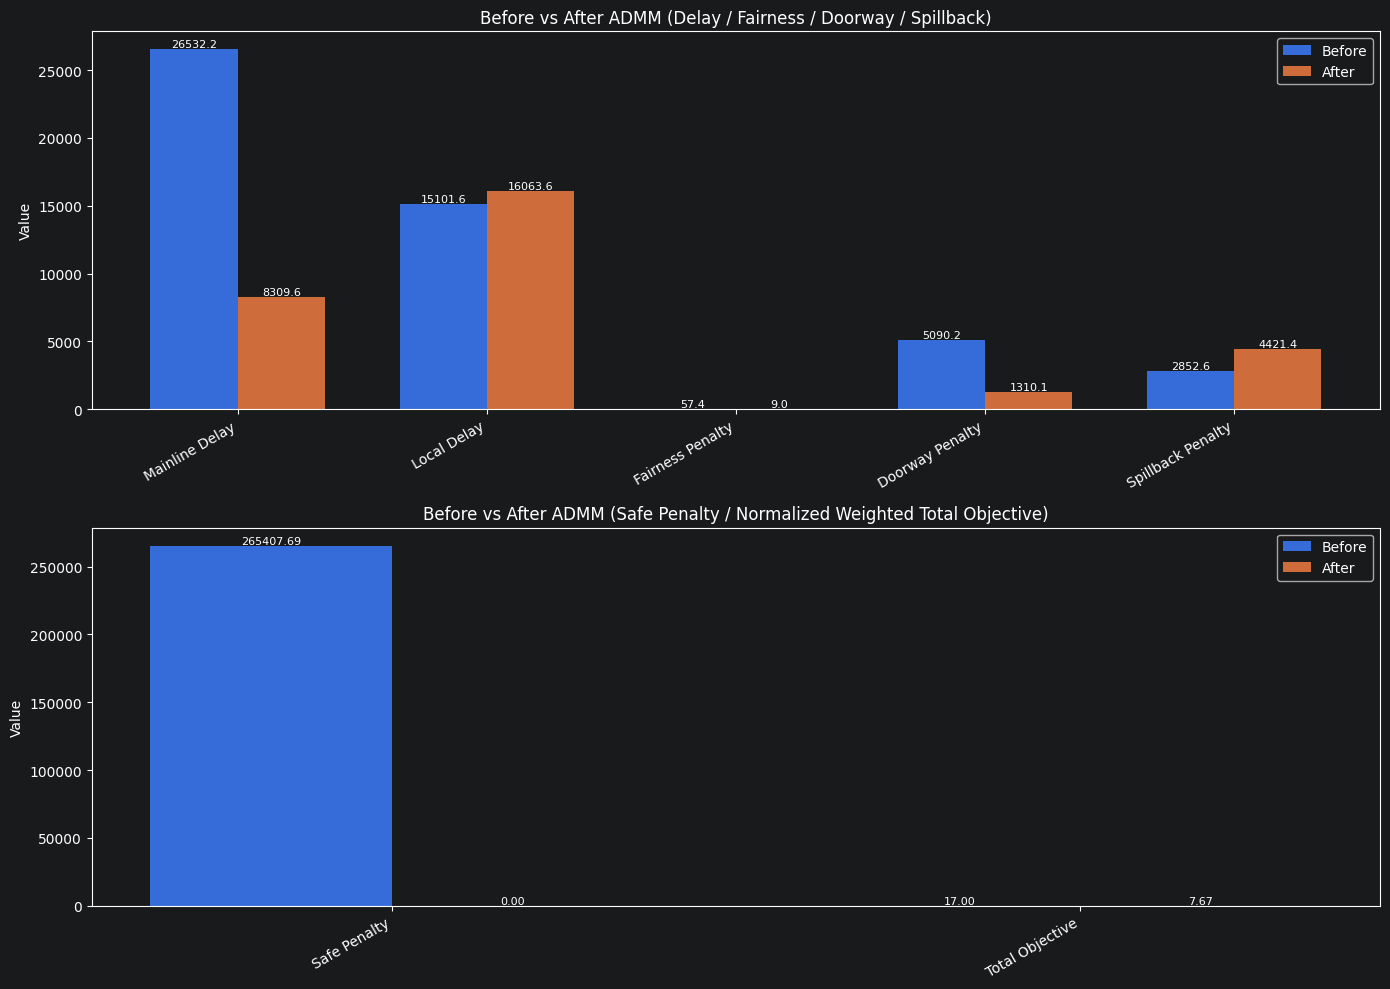

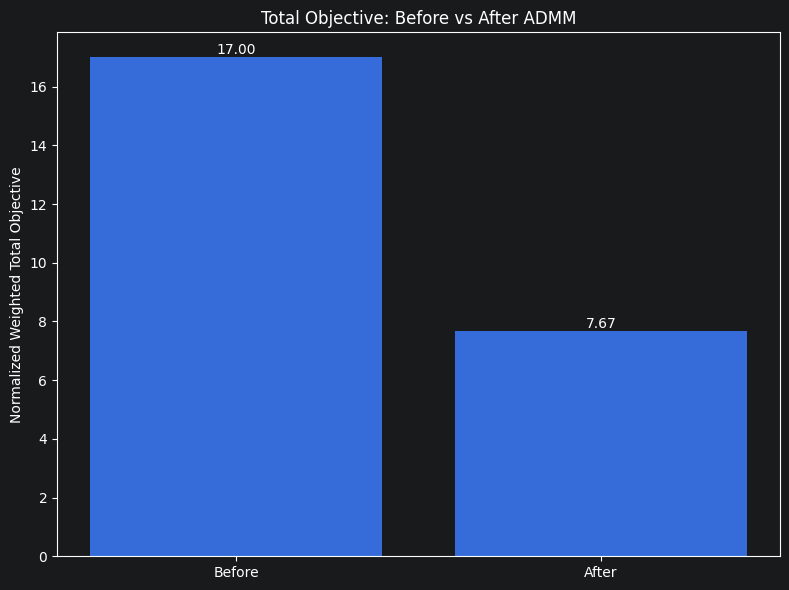

Before terms:
Mainline Delay 26532.175
Local Delay 15101.55
Fairness Penalty 57.361
Doorway Penalty 5090.232
Safe Threshold Penalty 265407.689
Physical Capacity Penalty 0.0
Spillback Penalty 2852.625
Total Capacity Penalty 273350.545

After terms:
Mainline Delay 8309.632
Local Delay 16063.569
Fairness Penalty 9.01
Doorway Penalty 1310.113
Safe Threshold Penalty 0.0
Physical Capacity Penalty 0.0
Spillback Penalty 4421.365
Total Capacity Penalty 5731.478

Normalized weighted total objective:
Before = 17.0
After  = 7.67


In [1120]:

import matplotlib.pyplot as plt
import numpy as np

# RAW totals for comparison
before_data = {
    "Mainline Delay": sum(history["mainline_delay"]),
    "Local Delay": sum(history["local_delay"]),
    "Fairness Penalty": sum(history["fairness_penalty"]),
    "Doorway Penalty": sum(history["doorway_penalty"]),
    "Safe Penalty": sum(history["safe_penalty"]),
    "Spillback Penalty": sum(history["spillback_penalty"])
}
after_data = {
    "Mainline Delay": sum(admm_history_120["mainline_delay"]),
    "Local Delay": sum(admm_history_120["local_delay"]),
    "Fairness Penalty": sum(admm_history_120["fairness_penalty"]),
    "Doorway Penalty": sum(admm_history_120["doorway_penalty"]),
    "Safe Penalty": sum(admm_history_120["safe_penalty"]),
    "Spillback Penalty": sum(admm_history_120["spillback_penalty"])
}

# use normalized weighted objective for BOTH before and after
before_main = sum(history["mainline_delay"])
before_local = sum(history["local_delay"])
before_fair_raw = sum(history["fairness_penalty"]) / gamma if gamma != 0 else 0.0
before_door_raw = sum(history["doorway_penalty"]) / lambda_1 if lambda_1 != 0 else 0.0
before_safe_raw = sum(history["safe_penalty"]) / lambda_2 if lambda_2 != 0 else 0.0
before_phys_raw = sum(history["physical_penalty"]) / lambda_3 if lambda_3 != 0 else 0.0
before_spill_raw = sum(history["spillback_penalty"]) / lambda_4 if lambda_4 != 0 else 0.0
after_main = sum(admm_history_120["mainline_delay"])
after_local = sum(admm_history_120["local_delay"])
after_fair_raw = sum(admm_history_120["fairness_penalty"]) / gamma if gamma != 0 else 0.0
after_door_raw = sum(admm_history_120["doorway_penalty"]) / lambda_1 if lambda_1 != 0 else 0.0
after_safe_raw = sum(admm_history_120["safe_penalty"]) / lambda_2 if lambda_2 != 0 else 0.0
after_phys_raw = sum(admm_history_120["physical_penalty"]) / lambda_3 if lambda_3 != 0 else 0.0
after_spill_raw = sum(admm_history_120["spillback_penalty"]) / lambda_4 if lambda_4 != 0 else 0.0
before_total_objective = (
    alpha_main * (before_main / D_main_base)
    + beta_local * (before_local / D_local_base)
    + gamma * (before_fair_raw / L_fair_base)
    + lambda_1 * (before_door_raw / P_door_base)
    + lambda_2 * (before_safe_raw / P_safe_base)
    + lambda_3 * (before_phys_raw / P_phys_base)
    + lambda_4 * (before_spill_raw / P_spill_base)
)
after_total_objective = (
    alpha_main * (after_main / D_main_base)
    + beta_local * (after_local / D_local_base)
    + gamma * (after_fair_raw / L_fair_base)
    + lambda_1 * (after_door_raw / P_door_base)
    + lambda_2 * (after_safe_raw / P_safe_base)
    + lambda_3 * (after_phys_raw / P_phys_base)
    + lambda_4 * (after_spill_raw / P_spill_base)
)
# add fair total objective
before_data["Total Objective"] = before_total_objective
after_data["Total Objective"] = after_total_objective


# GRAPH 1: component comparison, raw values except total objective

labels_small = [
    "Mainline Delay",
    "Local Delay",
    "Fairness Penalty",
    "Doorway Penalty",
    "Spillback Penalty"
]
labels_big = [
    "Safe Penalty",
    "Total Objective"
]
before_small = [before_data[label] for label in labels_small]
after_small = [after_data[label] for label in labels_small]
before_big = [before_data[label] for label in labels_big]
after_big = [after_data[label] for label in labels_big]
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
width = 0.35
# Top graph
x1 = np.arange(len(labels_small))
bars1 = axes[0].bar(x1 - width / 2, before_small, width, label="Before")
bars2 = axes[0].bar(x1 + width / 2, after_small, width, label="After")
axes[0].set_title("Before vs After ADMM (Delay / Fairness / Doorway / Spillback)")
axes[0].set_ylabel("Value")
axes[0].set_xticks(x1)
axes[0].set_xticklabels(labels_small, rotation=30, ha="right")
axes[0].legend()
for bar in bars1:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        rotation=0,
        fontsize=8
    )
for bar in bars2:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        rotation=0,
        fontsize=8
    )
# Bottom graph
x2 = np.arange(len(labels_big))
bars3 = axes[1].bar(x2 - width / 2, before_big, width, label="Before")
bars4 = axes[1].bar(x2 + width / 2, after_big, width, label="After")
axes[1].set_title("Before vs After ADMM (Safe Penalty / Normalized Weighted Total Objective)")
axes[1].set_ylabel("Value")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(labels_big, rotation=30, ha="right")
axes[1].legend()
for bar in bars3:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        rotation=0,
        fontsize=8
    )
for bar in bars4:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        rotation=0,
        fontsize=8
    )
plt.tight_layout()
plt.show()

# GRAPH 2: total objective only, normalized weighted total objective

labels = ["Before", "After"]
values = [before_total_objective, after_total_objective]
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values)
plt.ylabel("Normalized Weighted Total Objective")
plt.title("Total Objective: Before vs After ADMM")
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.tight_layout()
plt.show()


# penalty + delay + fairness printout
before_terms = {
    "Mainline Delay": sum(history["mainline_delay"]),
    "Local Delay": sum(history["local_delay"]),
    "Fairness Penalty": sum(history["fairness_penalty"]),
    "Doorway Penalty": sum(history["doorway_penalty"]),
    "Safe Threshold Penalty": sum(history["safe_penalty"]),
    "Physical Capacity Penalty": sum(history["physical_penalty"]),
    "Spillback Penalty": sum(history["spillback_penalty"]),
    "Total Capacity Penalty": sum(history["capacity_penalty"])
}

after_terms = {
    "Mainline Delay": sum(admm_history_120["mainline_delay"]),
    "Local Delay": sum(admm_history_120["local_delay"]),
    "Fairness Penalty": sum(admm_history_120["fairness_penalty"]),
    "Doorway Penalty": sum(admm_history_120["doorway_penalty"]),
    "Safe Threshold Penalty": sum(admm_history_120["safe_penalty"]),
    "Physical Capacity Penalty": sum(admm_history_120["physical_penalty"]),
    "Spillback Penalty": sum(admm_history_120["spillback_penalty"]),
    "Total Capacity Penalty": sum(admm_history_120["capacity_penalty"])
}

print("Before terms:")
for k, v in before_terms.items():
    print(k, round(v, 3))

print("\nAfter terms:")
for k, v in after_terms.items():
    print(k, round(v, 3))

print("\nNormalized weighted total objective:")
print("Before =", round(before_total_objective, 3))
print("After  =", round(after_total_objective, 3))

# How I normalized the objective
I divided every term in my objective by what that same term totalled in the baseline (uncontrolled) run. So when I score the baseline against itself, each term becomes baseline ÷ baseline = 1. Then multiplying by my weights gives:
10 (mainline) + 3 (local) + 2 (fairness) + 1 (doorway) + 0.5 (safe) + 0 (physical, since baseline never triggered it) + 0.5 (spillback) = 17.0
That's why my "before" number always equals 17 — it's just the sum of my weights. The data only sets the denominators.
When ADMM does better than baseline on a term, that term drops below 1. My "after" value of 11.5 means ADMM scored 68% of the baseline cost (11.5 ÷ 17.0), so a 32% reduction in the weighted objective.
When I report results, I should say "ADMM reduced the normalized weighted objective by 32%" — not "the objective dropped from 17 to 11.5." Otherwise readers might assume 17 has physical units like veh-min, but it doesn't. It's a dimensionless number defined by my weight choices.
The physical numbers I should quote are the raw ones from my results table: mainline delay 26,532 → 15,047 veh-min (−43%), safe penalty 265,407 → 0, and so on. Those are what carry traffic-engineering meaning. The 17 → 11.5 is just a single-number summary that rolls all those individual improvements into one.